In [1]:
# ── Data handling ──
import pandas as pd
import numpy as np

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine learning: preprocessing ──
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

# ── Machine learning: clustering algorithms ──
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

# ── Machine learning: evaluation metrics ──
from sklearn.metrics import silhouette_score         # overall mean Silhouette
from sklearn.metrics import silhouette_samples       # NEW: per-player Silhouette values
from sklearn.metrics import davies_bouldin_score     # DBI (lower = better)
from sklearn.metrics import calinski_harabasz_score  # NEW: CH Index (higher = better)
from sklearn.metrics import adjusted_rand_score      # NEW: compare two cluster assignments

# ── Hierarchical clustering dendrogram ──
from scipy.cluster.hierarchy import dendrogram, linkage  # NEW: for Agglomerative

# ── K-Modes (categorical clustering, not in scikit-learn) ──
!pip install kmodes
from kmodes.kmodes import KModes

# ── Suppress non-critical warnings ──
import warnings
warnings.filterwarnings("ignore")

# ── Global reproducibility seed ──
# This must be set here and passed to every algorithm below.
# Without it, results change on every run.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot styling ──
sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("All libraries imported successfully.")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   sklearn  {__import__('sklearn').__version__}")

All libraries imported successfully.
   pandas   2.2.2
   numpy    2.0.2
   sklearn  1.6.1


In [2]:
# Reads the NBA play-type CSV file from Google Drive into the notebook as a table with 207 players and 18 columns.
# Load the raw CSV from Google Drive
# Change this path if your CSV is stored in a different location
df_raw = pd.read_csv('/content/drive/MyDrive/playtype2019-2020.csv')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows    : {df_raw.shape[0]}")    # Should be 207
print(f"  Columns : {df_raw.shape[1]}")    # Should be 18
print("=" * 55)
print()
print("Column names as loaded (raw — note the mislabelled p&rr-pts):")
for col in df_raw.columns:
    print(f"  {col}")
print()
print("First 3 rows:")
print(df_raw.head(3))

  DATASET OVERVIEW
  Rows    : 207
  Columns : 18

Column names as loaded (raw — note the mislabelled p&rr-pts):
  Name
  Team
  Iso-freq
  iso-pts
  tra-freq
  tra-pts
  p&rh-freq
  p&rh-pts
  p&rr-pts
  p&rr-pts.1
  postup-freq
  postup-pts
  spotup-freq
  spotup-pts
  handoff-freq
  handoff-pts
  cut-freq
  cut-pts

First 3 rows:
                Name Team  Iso-freq  iso-pts  tra-freq  tra-pts  p&rh-freq  \
0       James Harden  HOU     0.450     1.12     0.199     1.10      0.179   
1  Russell Westbrook  OKC     0.250     0.87     0.245     1.01      0.124   
2     Damian Lillard  POR     0.179     1.07     0.097     1.17      0.517   

   p&rh-pts  p&rr-pts  p&rr-pts.1  postup-freq  postup-pts  spotup-freq  \
0      0.98       0.0         0.0         0.00         0.0        0.049   
1      0.93       0.0         0.0         0.09         0.8        0.146   
2      1.15       0.0         0.0         0.00         0.0        0.050   

   spotup-pts  handoff-freq  handoff-pts  cut-freq 

In [3]:
# Cleans the raw data. Renames messy column names, fixes a mislabelled column in the original file, removes any rows with missing player names, and fills in any gaps in the data using the median value of each column.
# ── Step 4.1: Rename all 18 columns to clean snake_case names ──
# The critical fix: 'p&rr-pts' is actually FREQUENCY (not PPP)
#                   'p&rr-pts.1' is the actual PPP column
COLUMN_MAP = {
    "Name"         : "player",
    "Team"         : "team",
    "Iso-freq"     : "iso_freq",
    "iso-pts"      : "iso_pts",
    "tra-freq"     : "tra_freq",
    "tra-pts"      : "tra_pts",
    "p&rh-freq"    : "prh_freq",
    "p&rh-pts"     : "prh_pts",
    "p&rr-pts"     : "prr_freq",    # ← CORRECTED: this is FREQUENCY not PPP
    "p&rr-pts.1"   : "prr_pts",     # ← CORRECTED: this is the actual PPP
    "postup-freq"  : "postup_freq",
    "postup-pts"   : "postup_pts",
    "spotup-freq"  : "spotup_freq",
    "spotup-pts"   : "spotup_pts",
    "handoff-freq" : "handoff_freq",
    "handoff-pts"  : "handoff_pts",
    "cut-freq"     : "cut_freq",
    "cut-pts"      : "cut_pts",
}
df = df_raw.rename(columns=COLUMN_MAP).copy()

# ── Step 4.2: Define column groups ──
# Grouping columns makes it easy to apply operations to all frequency
# or all PPP columns simultaneously throughout the pipeline.
META_COLS = ["player", "team"]   # Identifiers — NOT used in any modelling step
FREQ_COLS = ["iso_freq", "tra_freq", "prh_freq", "prr_freq",
              "postup_freq", "spotup_freq", "handoff_freq", "cut_freq"]
PPP_COLS  = ["iso_pts", "tra_pts", "prh_pts", "prr_pts",
              "postup_pts", "spotup_pts", "handoff_pts", "cut_pts"]
NUM_COLS  = FREQ_COLS + PPP_COLS   # All 16 numerical features combined
play_labels = ["Isolation", "Transition", "P&R Handler", "P&R Rollman",
                "Post-Up", "Spot-Up", "Hand-Off", "Cut"]

# ── Step 4.3: Remove rows with missing player names ──
before = len(df)
df = df.dropna(subset=["player"])
print(f"Step 4.3 — Rows removed (missing player name): {before - len(df)}")

# ── Step 4.4: Fill the one missing team value ──
# Team is metadata only — not used in clustering.
# One player had no team (mid-season trade). Fill with 'Unknown' to keep the row.
df["team"] = df["team"].fillna("Unknown")

# ── Step 4.5: Flag impossible values as NaN ──
# Frequency must be in [0, 1] — it's a proportion of possessions (0% to 100%)
# PPP must be in [0, 3] — maximum 3 points per possession (and-one)
# Values outside these ranges = data entry errors → set to NaN → imputed next step
for col in PPP_COLS:
    invalid = (df[col] < 0) | (df[col] > 3)
    if invalid.any():
        print(f"  Step 4.5 — Invalid PPP in '{col}': {invalid.sum()} values")
        df.loc[invalid, col] = np.nan
for col in FREQ_COLS:
    invalid = (df[col] < 0) | (df[col] > 1)
    if invalid.any():
        print(f"  Step 4.5 — Invalid FREQ in '{col}': {invalid.sum()} values")
        df.loc[invalid, col] = np.nan

# ── Step 4.6: Impute remaining NaN values with column MEDIAN ──
# WHY MEDIAN: Right-skewed distributions (shown in EDA Cell 5).
# Mean is pulled upward by elite high-usage players — unrepresentative.
# Median (middle value) is robust to skew and outliers.
imputer = SimpleImputer(strategy="median")
df[NUM_COLS] = imputer.fit_transform(df[NUM_COLS])

# ── Step 4.7: Reset row index to consecutive integers ──
# After dropping rows, index has gaps (0, 1, 3, 5...).
# Reset gives clean 0, 1, 2, 3... needed for k-NN row lookups in Cell 7.
df.reset_index(drop=True, inplace=True)

print(f"\nDataset after preprocessing: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values remaining    : {df[NUM_COLS].isnull().sum().sum()}")
print()
print(df.head(3))

Step 4.3 — Rows removed (missing player name): 0

Dataset after preprocessing: 207 rows × 18 columns
Missing values remaining    : 0

              player team  iso_freq  iso_pts  tra_freq  tra_pts  prh_freq  \
0       James Harden  HOU     0.450     1.12     0.199     1.10     0.179   
1  Russell Westbrook  OKC     0.250     0.87     0.245     1.01     0.124   
2     Damian Lillard  POR     0.179     1.07     0.097     1.17     0.517   

   prh_pts  prr_freq  prr_pts  postup_freq  postup_pts  spotup_freq  \
0     0.98       0.0      0.0         0.00         0.0        0.049   
1     0.93       0.0      0.0         0.09         0.8        0.146   
2     1.15       0.0      0.0         0.00         0.0        0.050   

   spotup_pts  handoff_freq  handoff_pts  cut_freq  cut_pts  
0        1.26         0.027         1.14     0.016     1.32  
1        0.88         0.016         0.89     0.024     1.07  
2        1.19         0.050         1.09     0.014     1.16  


  SUMMARY STATISTICS — FREQUENCY COLUMNS
       iso_freq  tra_freq  prh_freq  prr_freq  postup_freq  spotup_freq  handoff_freq  cut_freq
count   207.000   207.000   207.000   207.000      207.000      207.000       207.000   207.000
mean      0.059     0.156     0.179     0.061        0.050        0.211         0.048     0.067
std       0.058     0.057     0.163     0.089        0.073        0.115         0.044     0.069
min       0.000     0.024     0.000     0.000        0.000        0.000         0.000     0.000
25%       0.018     0.118     0.024     0.000        0.000        0.127         0.000     0.022
50%       0.049     0.150     0.138     0.010        0.000        0.204         0.044     0.046
75%       0.091     0.187     0.314     0.102        0.085        0.293         0.072     0.082
max       0.450     0.322     0.552     0.306        0.368        0.575         0.239     0.381

  SUMMARY STATISTICS — PPP COLUMNS
       iso_pts  tra_pts  prh_pts  prr_pts  postup_pts  spot

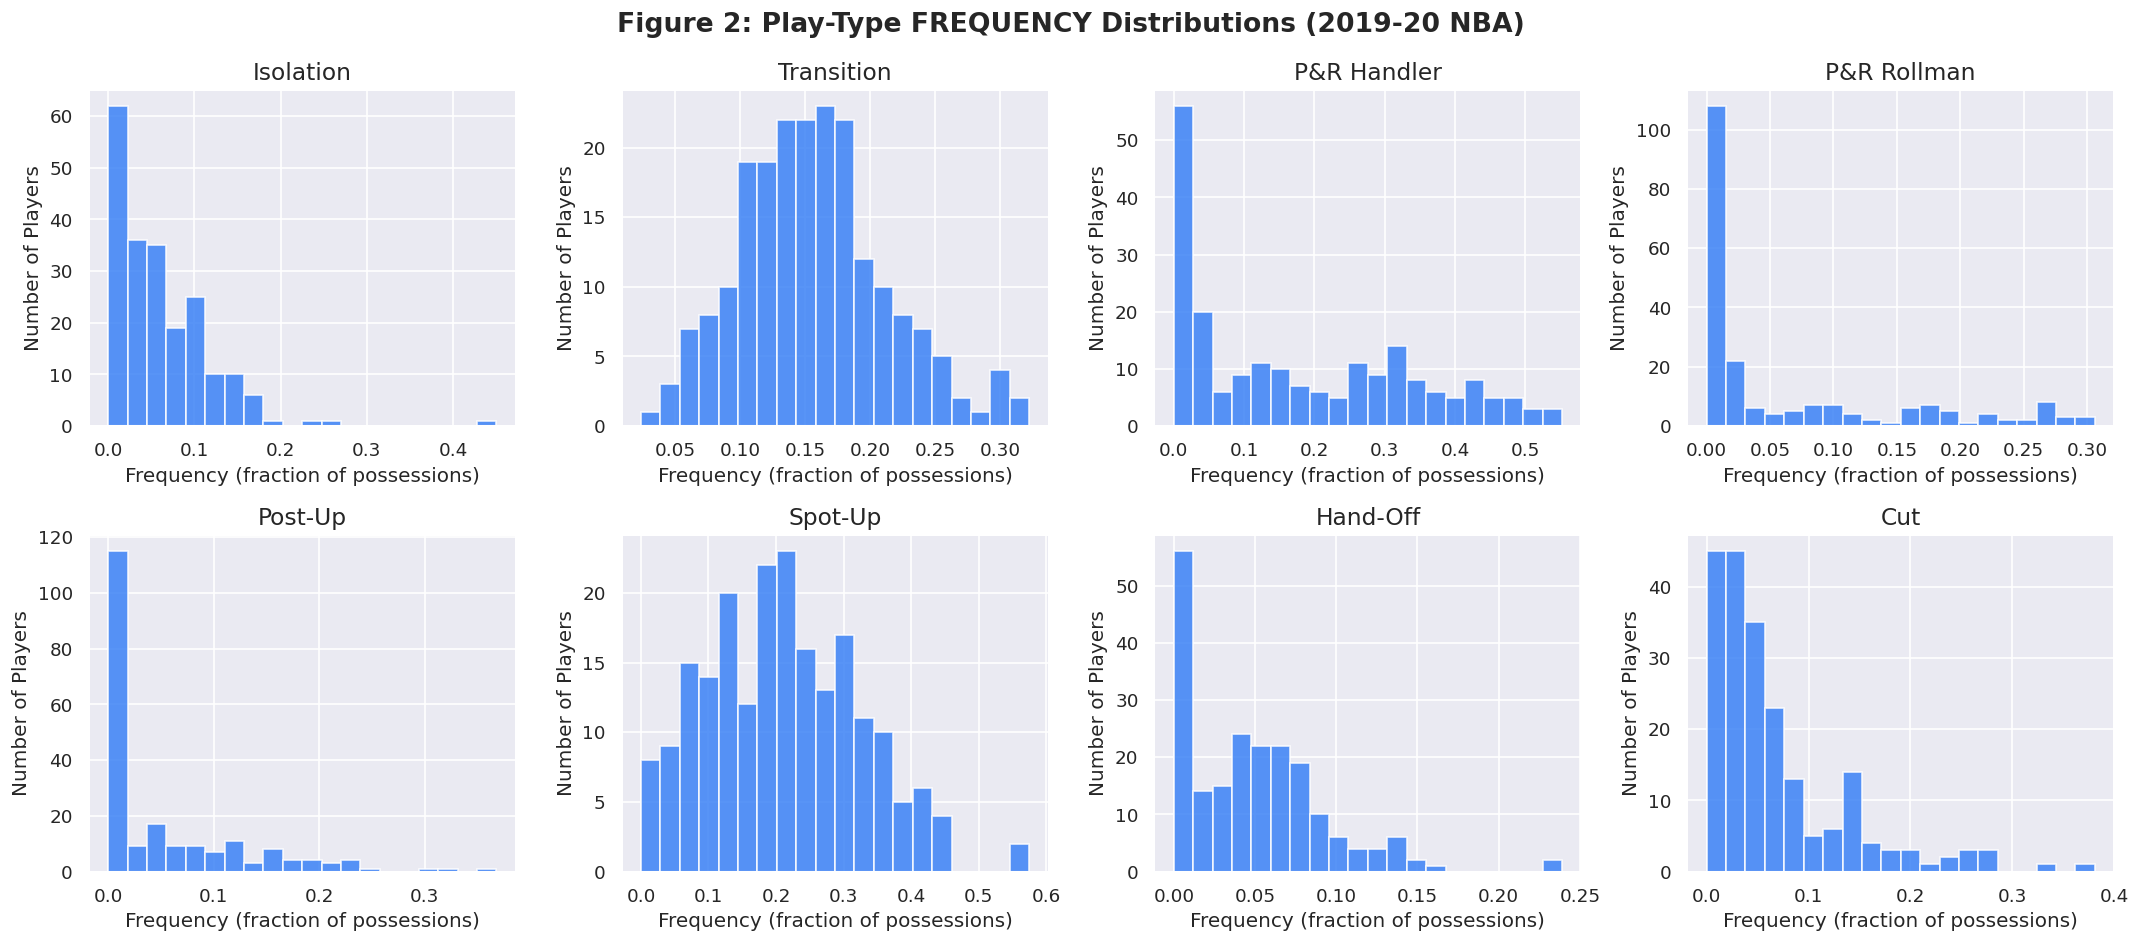

Figure 2 saved.


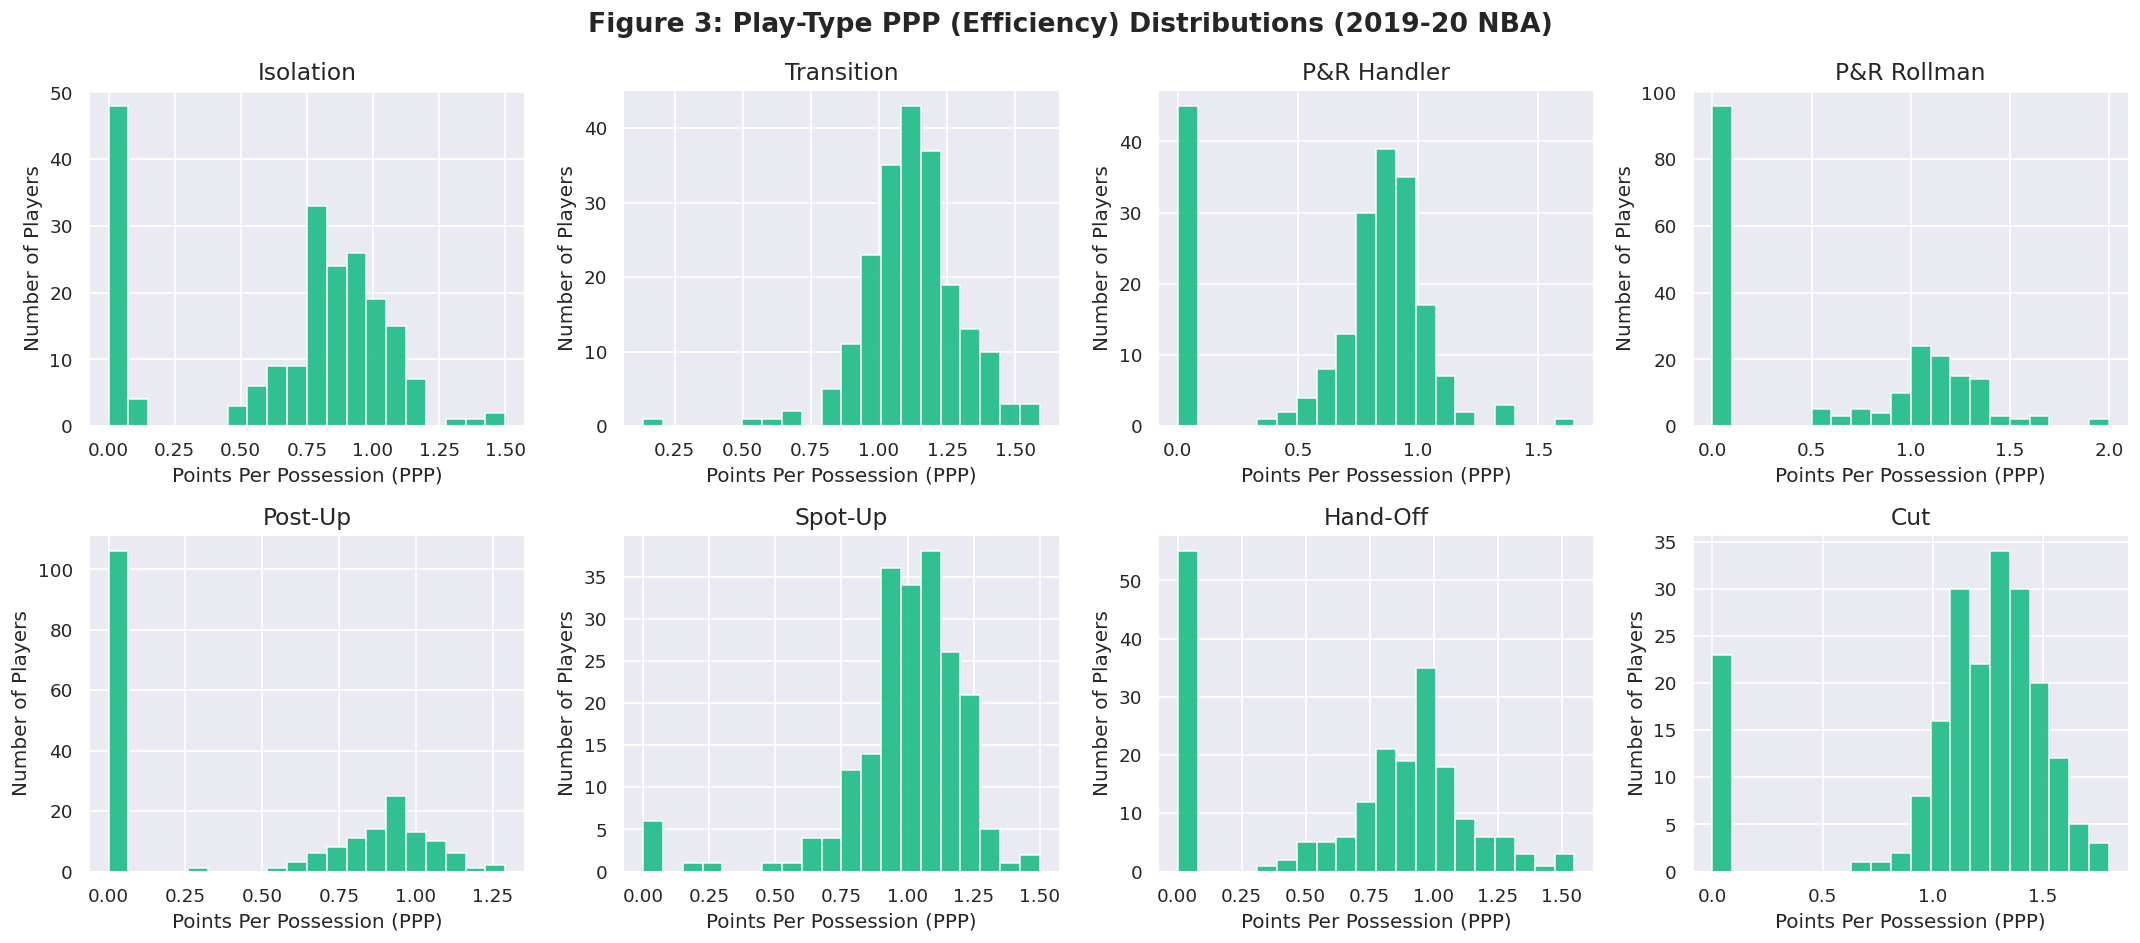

Figure 3 saved.


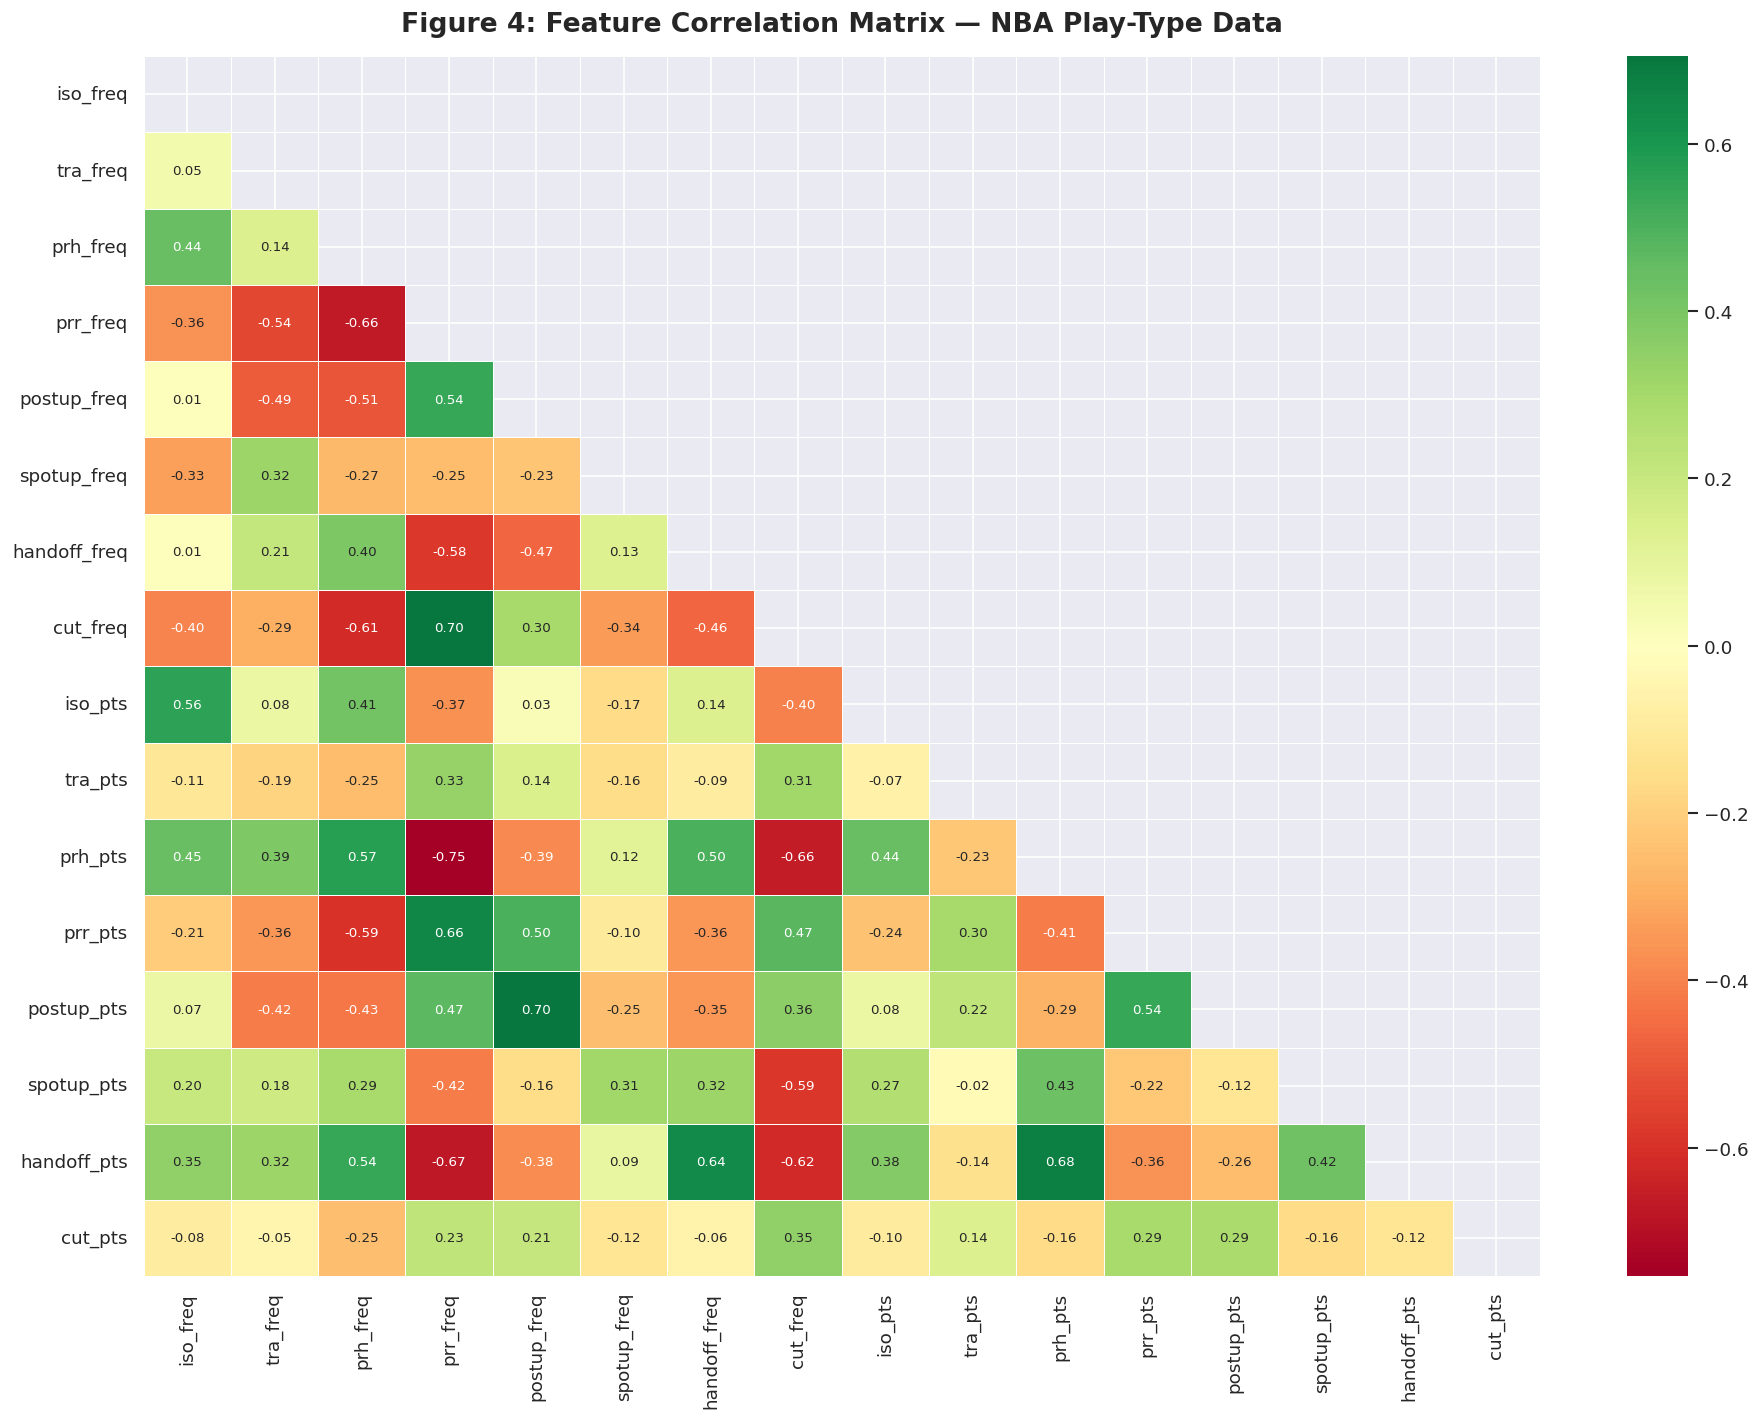

Figure 4 saved.


In [4]:
# Produces three charts to understand the data before any modelling. Frequency histograms, PPP efficiency histograms, and a correlation heatmap showing how features relate to each other.
# ── Summary statistics ──
print("=" * 55)
print("  SUMMARY STATISTICS — FREQUENCY COLUMNS")
print("=" * 55)
print(df[FREQ_COLS].describe().round(3).to_string())
print()
print("=" * 55)
print("  SUMMARY STATISTICS — PPP COLUMNS")
print("=" * 55)
print(df[PPP_COLS].describe().round(3).to_string())

# ── Figure 2: Frequency Distribution Histograms ──
# What to look for: the SHAPE. Most are right-skewed (long tail to the right).
# iso_freq is the most extreme: most players near 0, Harden at 0.450.
# This right-skew is WHY we use IQR for outlier removal in Cell 6.
# (IQR is non-parametric — no assumption about distribution shape.
#  Z-score assumes Gaussian/normal distribution — these clearly are NOT.)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Figure 2: Play-Type FREQUENCY Distributions (2019-20 NBA)",
             fontsize=16, fontweight="bold")
for ax, col, label in zip(axes.flatten(), FREQ_COLS, play_labels):
    ax.hist(df[col], bins=20, color="#3B82F6", edgecolor="white", alpha=0.85)
    ax.set_title(label)
    ax.set_xlabel("Frequency (fraction of possessions)")
    ax.set_ylabel("Number of Players")
plt.tight_layout()
plt.savefig("eda_freq_histograms.png", bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

# ── Figure 3: PPP Efficiency Histograms ──
# What to look for: cut_pts and tra_pts have the highest average values.
# iso_pts has the lowest — one-on-one against a set defender is the hardest way to score.
# More normally distributed than frequency histograms.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Figure 3: Play-Type PPP (Efficiency) Distributions (2019-20 NBA)",
             fontsize=16, fontweight="bold")
for ax, col, label in zip(axes.flatten(), PPP_COLS, play_labels):
    ax.hist(df[col], bins=20, color="#10B981", edgecolor="white", alpha=0.85)
    ax.set_title(label)
    ax.set_xlabel("Points Per Possession (PPP)")
    ax.set_ylabel("Number of Players")
plt.tight_layout()
plt.savefig("eda_ppp_histograms.png", bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

# ── Figure 4: Pearson Correlation Heatmap ──
# KEY CORRELATIONS TO REMEMBER:
#   iso_freq ↔ prh_freq = +0.44 → POSITIVE: both are ball-dominant actions.
#     Same player type (primary ball-handler) uses both.
#     → Validates the on_ball_creation composite feature (Cell 8)
#
#   cut_freq ↔ spotup_freq = -0.34 → NEGATIVE: different off-ball roles.
#     Cutters and spot-up shooters are distinct player types even though
#     neither requires the player to initiate.
#     → Validates off_ball_finishing as a meaningful concept (Cell 8)
#
#   iso_freq ↔ iso_pts = +0.56 → POSITIVE: elite ISO scorers attempt more
#     AND convert better. Self-selection effect — poor iso scorers get
#     coached away from isolation. Only the good ones accumulate high frequency.
#
# Lower triangle only because matrix is symmetric (A↔B = B↔A — showing both = redundant)
corr_matrix = df[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # True = hide upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Figure 4: Feature Correlation Matrix — NBA Play-Type Data",
             fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

📊 Figure 5: Boxplots BEFORE Outlier Removal


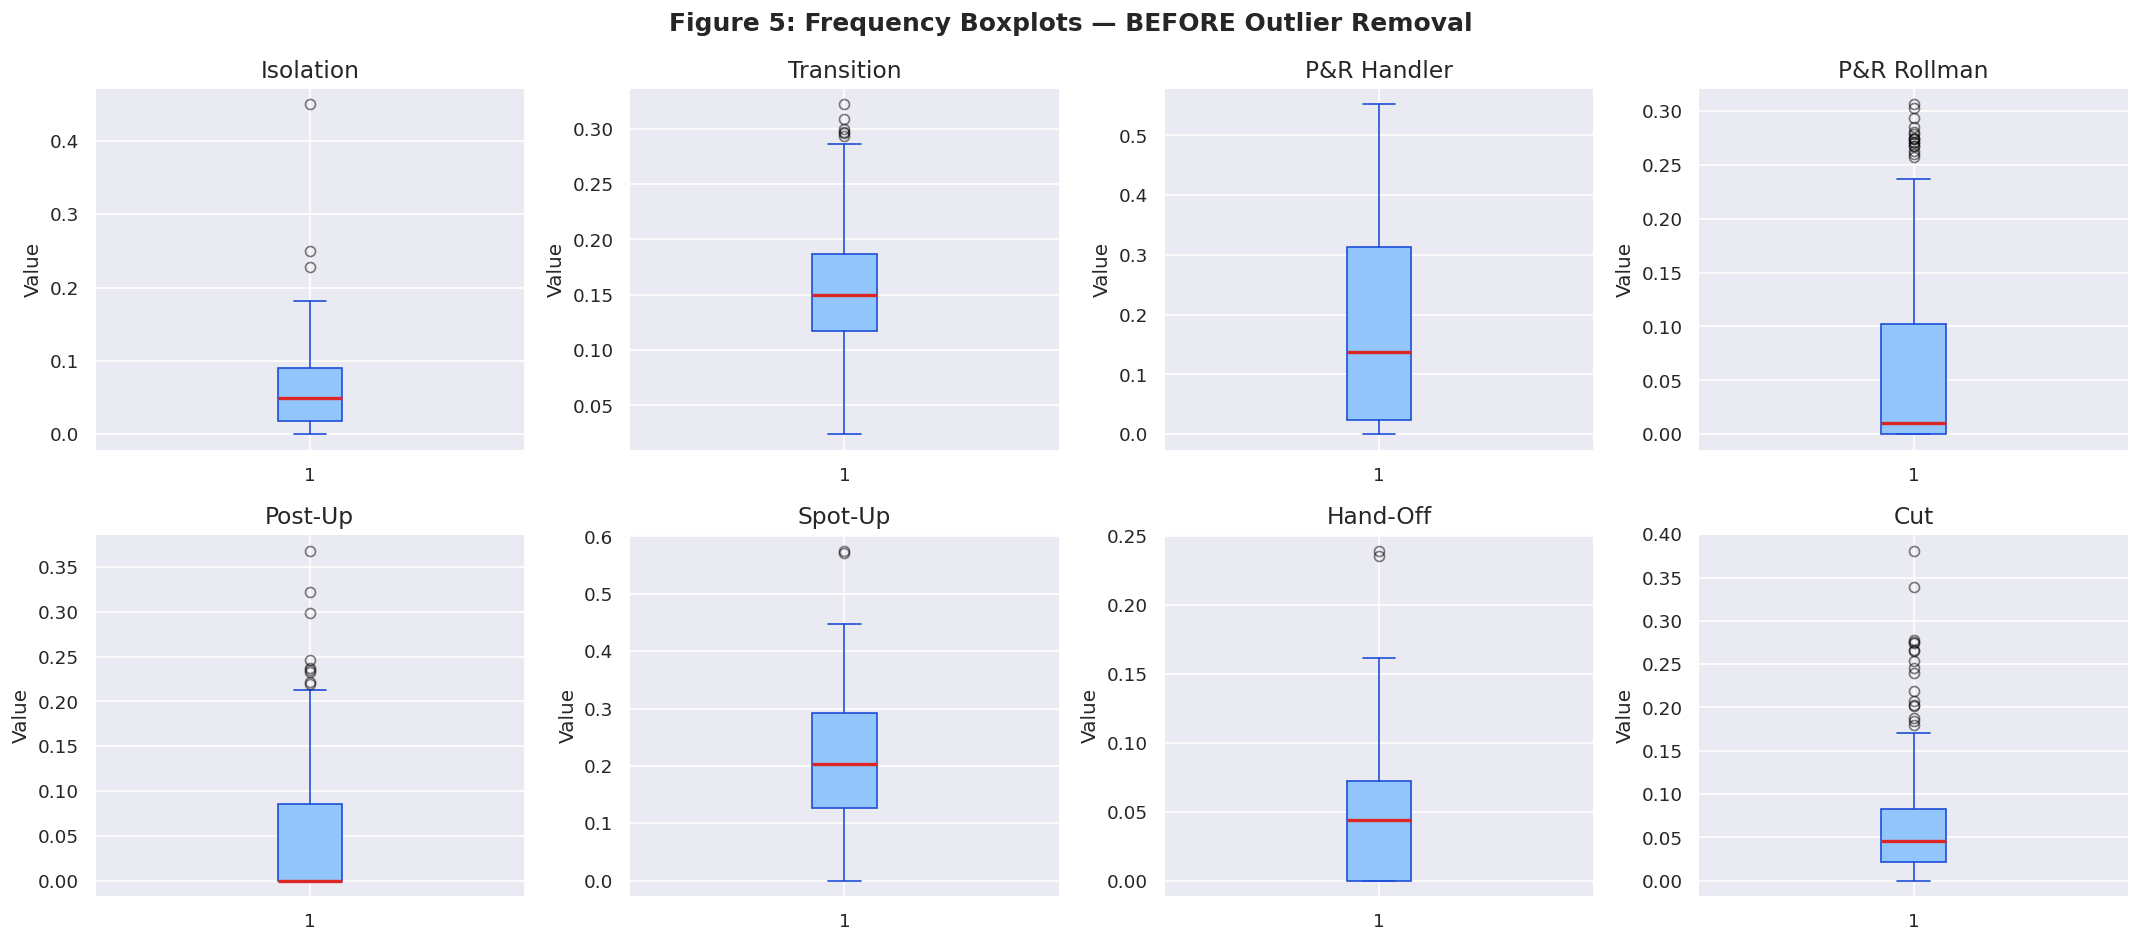


📋 Outlier Removal Report (IQR × 1.5):
  Feature                  Flagged  Why these rows were flagged
  ---------------------------------------------------------------------------
  prh_pts                       46 rows  — Players who rarely use P&R have very few possessions → extreme PPP from tiny sample
  cut_pts                       23 rows  — Same issue — infrequent cutters have unreliable efficiency values
  cut_freq                      17 rows  — High-frequency cutters at one extreme, guards who never cut at the other
  prr_freq                      16 rows  — Guards with zero rollman involvement flagged as extreme low values
  spotup_pts                    11 rows  — Extreme values at one or both ends of the distribution
  postup_freq                    9 rows  — Extreme values at one or both ends of the distribution
  tra_pts                        8 rows  — Very few transition possessions → volatile PPP statistic
  tra_freq                       6 rows  — Extreme values at 

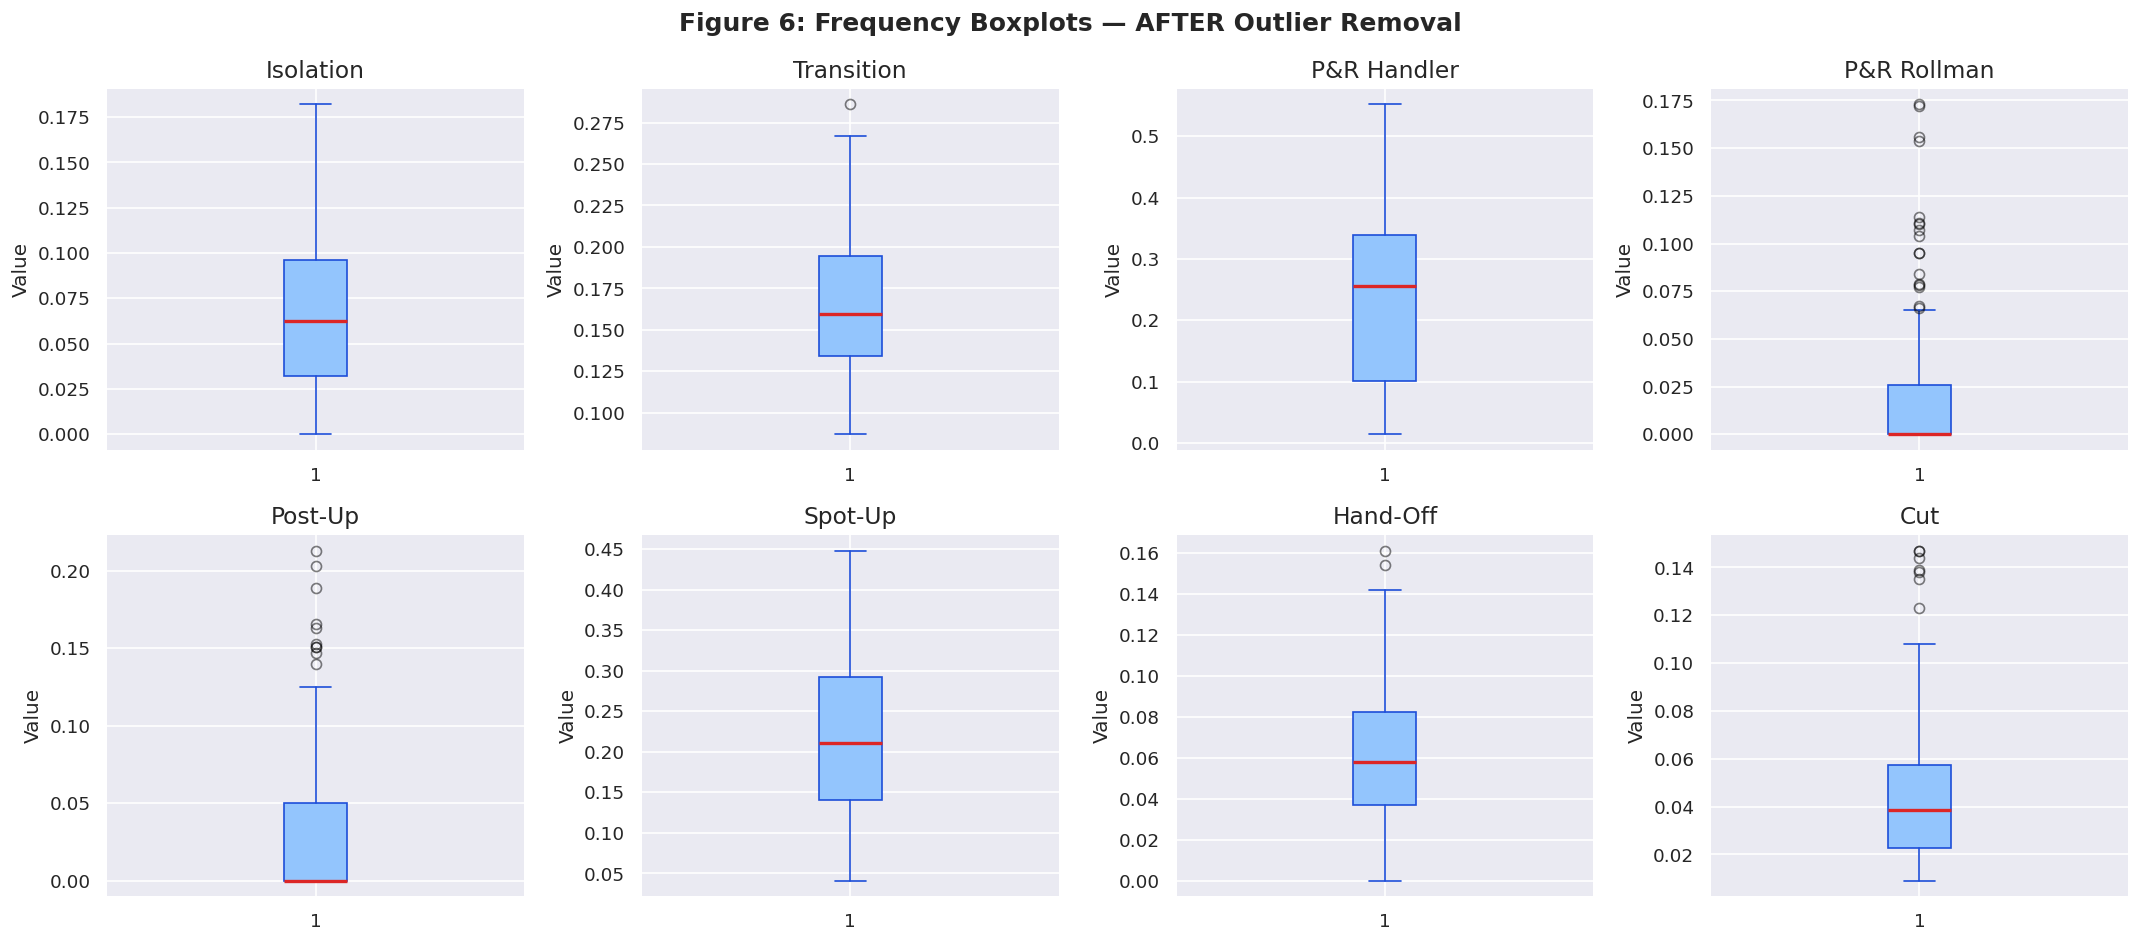

In [5]:
# Removes players with extreme values using the IQR method. Produces boxplots before and after to show the effect. Dataset reduces from 207 to 120 players.
# ── Helper function: draw boxplots ──
# Orange dots above/below the whiskers = potential outlier points
# After removal, these orange dots should be largely gone
def plot_boxplots(data, cols, labels, title, filename):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(title, fontsize=15, fontweight="bold")
    for ax, col, label in zip(axes.flatten(), cols, labels):
        ax.boxplot(
            data[col].dropna(),
            patch_artist=True,
            boxprops=dict(facecolor="#93C5FD", color="#1D4ED8"),
            medianprops=dict(color="#DC2626", linewidth=2),
            whiskerprops=dict(color="#1D4ED8"),
            capprops=dict(color="#1D4ED8"),
            flierprops=dict(marker="o", color="#F59E0B", alpha=0.5),
        )
        ax.set_title(label)
        ax.set_ylabel("Value")
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

# Figure 5: Boxplots BEFORE removal (note orange dots = outliers to be removed)
print("📊 Figure 5: Boxplots BEFORE Outlier Removal")
plot_boxplots(df, FREQ_COLS, play_labels,
              "Figure 5: Frequency Boxplots — BEFORE Outlier Removal",
              "boxplot_freq_before.png")

# ── IQR Outlier Removal Function ──
def remove_outliers_iqr(data, cols, multiplier=1.5):
    """
    Remove any row where at least one feature value falls outside
    the IQR fence: [Q1 - multiplier*IQR,  Q3 + multiplier*IQR]
    Returns cleaned DataFrame + report of how many rows each column flagged.
    """
    keep_mask = pd.Series([True] * len(data), index=data.index)
    report = {}
    for col in cols:
        Q1  = data[col].quantile(0.25)
        Q3  = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        in_bounds = (data[col] >= lower) & (data[col] <= upper)
        n_out = (~in_bounds).sum()
        if n_out > 0:
            report[col] = n_out
        keep_mask = keep_mask & in_bounds    # row kept only if ALL features in bounds
    return data[keep_mask].copy(), report

df_clean = df.copy()
before_count = len(df_clean)
df_clean, outlier_report = remove_outliers_iqr(df_clean, NUM_COLS, multiplier=1.5)
removed = before_count - len(df_clean)

# Print the report
print(f"\n📋 Outlier Removal Report (IQR × 1.5):")
print(f"  {'Feature':<22}  {'Flagged':>8}  Why these rows were flagged")
print("  " + "-" * 75)
explanations = {
    "prh_pts":      "Players who rarely use P&R have very few possessions → extreme PPP from tiny sample",
    "cut_pts":      "Same issue — infrequent cutters have unreliable efficiency values",
    "cut_freq":     "High-frequency cutters at one extreme, guards who never cut at the other",
    "prr_freq":     "Guards with zero rollman involvement flagged as extreme low values",
    "tra_pts":      "Very few transition possessions → volatile PPP statistic",
    "iso_freq":     "Elite ISO scorers (Harden=0.450) flagged — they are the signal, not noise",
}
for col, count in sorted(outlier_report.items(), key=lambda x: -x[1]):
    why = explanations.get(col, "Extreme values at one or both ends of the distribution")
    print(f"  {col:<22}  {count:>8} rows  — {why}")

print(f"\n  Rows before : {before_count}")
print(f"  Rows removed: {removed}  ({removed/before_count*100:.1f}% of dataset)")
print(f"  Rows after  : {len(df_clean)}")
print(f"\n  LIMITATION: IQR×1.5 is too aggressive for sports data.")
print(f"  Elite specialists (Harden iso=0.450) are genuine players, not errors.")
print(f"  Future work: use IQR×2.5 or winsorise (cap values, don't delete rows).")

df_clean.reset_index(drop=True, inplace=True)

# Figure 6: Boxplots AFTER removal (orange dots should mostly be gone)
print("\n📊 Figure 6: Boxplots AFTER Outlier Removal")
plot_boxplots(df_clean, FREQ_COLS, play_labels,
              "Figure 6: Frequency Boxplots — AFTER Outlier Removal",
              "boxplot_freq_after.png")

In [6]:
print(f"Dataset size before augmentation: {len(df_clean)} players")

# Creates 180 synthetic players to expand the dataset from 120 to 300. Uses Gaussian noise for local variation and k-NN interpolation to fill gaps between similar real players.
# ── METHOD 1: Gaussian Noise Injection ──
# Creates synthetic copies by adding small random noise to real players.
# Each synthetic player is very similar to their real parent (local variation).
def augment_gaussian(data, cols, noise_factor=0.05, n_copies=1, seed=42):
    rng = np.random.default_rng(seed)
    frames = [data.copy()]       # start list with the original real data
    stds = data[cols].std()      # compute standard deviation of each feature

    for _ in range(n_copies):   # n_copies=1 means: one synthetic copy per real player
        noisy = data.copy()
        # Draw noise: Normal(mean=0, SD=5% of each feature's SD)
        # Shape: (n_players, n_features) — one noise value per feature per player
        noise = rng.normal(
            loc=0,
            scale=(stds * noise_factor).values,
            size=(len(data), len(cols))
        )
        noisy[cols] = data[cols].values + noise

        # Clip to valid physical ranges after adding noise
        for col in [c for c in cols if "freq" in c]:
            noisy[col] = noisy[col].clip(0, 1.0)   # frequency max = 100%
        for col in [c for c in cols if "pts" in c]:
            noisy[col] = noisy[col].clip(0, 3.0)   # PPP max = 3.0

        # Mark as synthetic so dashboard can filter them out
        noisy["player"] = noisy["player"].apply(lambda x: f"{x}_aug_gauss")
        frames.append(noisy)

    return pd.concat(frames, ignore_index=True)

df_aug = augment_gaussian(df_clean, NUM_COLS, noise_factor=0.05, n_copies=1)
print(f"Method 1 — Gaussian Noise    : 120 → {len(df_aug)} (+{len(df_aug)-len(df_clean)} synthetic copies)")

# ── METHOD 2: k-NN Interpolation ──
# Creates synthetic players that sit BETWEEN two similar real players.
# Fills distributional gaps rather than just adding local noise.
def augment_knn_interpolation(data, cols, n_neighbors=3, n_synthetic=60, seed=42):
    rng = np.random.default_rng(seed)
    X = data[cols].values

    # Build k-nearest-neighbours index
    # n_neighbors+1 because index 0 is the point itself (we skip it)
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1, algorithm="ball_tree").fit(X)
    _, indices = nbrs.kneighbors(X)   # indices[i] = row indices of i's neighbours

    synthetic_rows = []
    for _ in range(n_synthetic):
        i   = rng.integers(0, len(data))        # pick random real player i
        j   = rng.choice(indices[i][1:])         # pick random neighbour j (skip [0] = self)
        lam = rng.uniform(0.2, 0.8)             # blending weight λ ∈ [0.2, 0.8]

        # Linear interpolation: synth = λ×player_i + (1-λ)×player_j
        synth = data.iloc[i].copy()
        synth[cols] = (lam * data.iloc[i][cols].values +
                       (1 - lam) * data.iloc[j][cols].values)
        synth["player"] = f"Synth_{i}_{j}"   # label showing parent indices
        synth["team"]   = "SYN"               # team = SYN marks it as synthetic
        synthetic_rows.append(synth)

    synth_df = pd.DataFrame(synthetic_rows)
    return pd.concat([data, synth_df], ignore_index=True)

df_aug = augment_knn_interpolation(df_aug, NUM_COLS, n_neighbors=3, n_synthetic=60)
print(f"Method 2 — k-NN Interpolation: 240 → {len(df_aug)} (+60 interpolated players)")
print()
print("─" * 50)
print(f"  FINAL DATASET SIZE: {len(df_aug)} observations")
print(f"    120 real players")
print(f"    120 Gaussian noise copies  (_aug_gauss)")
print(f"     60 k-NN interpolated      (Synth_i_j)")
print("─" * 50)
print()
print("IMPORTANT: Evaluation metrics will be computed on ORIGINAL 120 ONLY.")
print("Synthetic players help training — they are never used in evaluation.")

Dataset size before augmentation: 120 players
Method 1 — Gaussian Noise    : 120 → 240 (+120 synthetic copies)
Method 2 — k-NN Interpolation: 240 → 300 (+60 interpolated players)

──────────────────────────────────────────────────
  FINAL DATASET SIZE: 300 observations
    120 real players
    120 Gaussian noise copies  (_aug_gauss)
     60 k-NN interpolated      (Synth_i_j)
──────────────────────────────────────────────────

IMPORTANT: Evaluation metrics will be computed on ORIGINAL 120 ONLY.
Synthetic players help training — they are never used in evaluation.


In [7]:
df_feat = df_aug.copy()   # work on a copy — always preserve the augmented source

# Creates 8 new combined features from the existing 16, capturing basketball concepts like overall ball dominance, weighted efficiency, and how many different play types a player uses meaningfully. Total features go from 16 to 24.

# ── Feature 1: On-Ball Creation ──
# = iso_freq + prh_freq + postup_freq + handoff_freq
# All four play types where the player IS the primary decision-maker with the ball.
# Expected mean: ~0.40 (players use ~40% of possessions in ball-dominant ways on average)
df_feat["on_ball_creation"] = (df_feat["iso_freq"] + df_feat["prh_freq"] +
                                df_feat["postup_freq"] + df_feat["handoff_freq"])

# ── Feature 2: Off-Ball Finishing ──
# = cut_freq + spotup_freq + prr_freq
# All three play types where the player benefits from TEAMMATE-CREATED space.
# Expected mean: ~0.29
df_feat["off_ball_finishing"] = (df_feat["cut_freq"] + df_feat["spotup_freq"] +
                                  df_feat["prr_freq"])

# ── Features 3-6: Impact Scores (frequency × PPP) ──
# WHY MULTIPLY: Frequency alone ignores quality. PPP alone ignores volume.
# Impact = meaningful contribution balancing both volume AND efficiency.
df_feat["transition_impact"] = df_feat["tra_freq"]    * df_feat["tra_pts"]    # mean ~0.19
df_feat["iso_impact"]         = df_feat["iso_freq"]    * df_feat["iso_pts"]    # mean ~0.06 (very low)
df_feat["prh_impact"]         = df_feat["prh_freq"]    * df_feat["prh_pts"]    # mean ~0.20
df_feat["spotup_impact"]      = df_feat["spotup_freq"] * df_feat["spotup_pts"] # mean ~0.23

# ── Feature 7: Overall Efficiency ──
# = Σ(freq_i × pts_i) / Σ(freq_i)  — frequency-weighted average PPP
# This weights each play type's efficiency by how often the player uses it.
# A player who mostly cuts (high PPP=1.14) scores higher than one who mostly isolates
# (low PPP=0.66), even if their raw per-play PPP happens to be identical.
# Expected mean: ~1.0 PPP (approximately the NBA league average)
# EPS prevents division-by-zero (impossible with real players but safe for edge cases)
EPS = 1e-9
total_freq = (df_feat["iso_freq"] + df_feat["tra_freq"] + df_feat["prh_freq"] +
              df_feat["prr_freq"] + df_feat["postup_freq"] + df_feat["spotup_freq"] +
              df_feat["handoff_freq"] + df_feat["cut_freq"] + EPS)
weighted_ppp = (df_feat["iso_freq"]     * df_feat["iso_pts"]     +
                df_feat["tra_freq"]     * df_feat["tra_pts"]     +
                df_feat["prh_freq"]     * df_feat["prh_pts"]     +
                df_feat["prr_freq"]     * df_feat["prr_pts"]     +
                df_feat["postup_freq"]  * df_feat["postup_pts"]  +
                df_feat["spotup_freq"]  * df_feat["spotup_pts"]  +
                df_feat["handoff_freq"] * df_feat["handoff_pts"] +
                df_feat["cut_freq"]     * df_feat["cut_pts"])
df_feat["overall_efficiency"] = weighted_ppp / total_freq

# ── Feature 8: Play Diversity ──
# = count of play types where frequency > 5% (1 in 20 possessions)
# WHY 5%: Below 5% = incidental, not a regular part of the repertoire.
# Low scores (1-2): specialist (e.g., plays almost exclusively as a spot-up shooter)
# High scores (5-6): versatile (e.g., Giannis — posts up, rolls, cuts, runs transition)
THRESH = 0.05
df_feat["play_diversity"] = (df_feat[FREQ_COLS] > THRESH).sum(axis=1).astype(float)

# ── Collect all feature names ──
ENGINEERED_COLS = ["on_ball_creation", "off_ball_finishing",
                    "transition_impact", "iso_impact", "prh_impact", "spotup_impact",
                    "overall_efficiency", "play_diversity"]
MODEL_FEATURES = NUM_COLS + ENGINEERED_COLS   # 16 base + 8 engineered = 24 total

print("Engineered features added:")
for f in ENGINEERED_COLS:
    print(f"  ✔  {f}")
print(f"\nTotal modelling features : {len(MODEL_FEATURES)}")
print(f"Dataset shape            : {df_feat.shape}")
print()
print("Engineered feature statistics:")
print(df_feat[ENGINEERED_COLS].describe().round(3))

Engineered features added:
  ✔  on_ball_creation
  ✔  off_ball_finishing
  ✔  transition_impact
  ✔  iso_impact
  ✔  prh_impact
  ✔  spotup_impact
  ✔  overall_efficiency
  ✔  play_diversity

Total modelling features : 24
Dataset shape            : (300, 26)

Engineered feature statistics:
       on_ball_creation  off_ball_finishing  transition_impact  iso_impact  \
count           300.000             300.000            300.000     300.000   
mean              0.398               0.290              0.187       0.061   
std               0.166               0.123              0.055       0.046   
min               0.051               0.059              0.089       0.000   
25%               0.261               0.193              0.149       0.025   
50%               0.418               0.268              0.176       0.053   
75%               0.530               0.392              0.220       0.092   
max               0.753               0.588              0.326       0.192   

      

In [8]:
X_raw = df_feat[MODEL_FEATURES].copy()   # extract the 24 features as a matrix (300×24)

# Puts all 24 features on the same scale so no single feature dominates just because its numbers are bigger. This step is required before PCA.
# fit_transform does two things:
#   (1) fit = learn the mean and SD from the data
#   (2) transform = apply: new_value = (value - mean) / SD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)   # returns numpy array of shape (300, 24)
X_scaled_df = pd.DataFrame(X_scaled, columns=MODEL_FEATURES)

print(f"Scaled feature matrix: {X_scaled.shape[0]} players × {X_scaled.shape[1]} features")
print()
print("Verification — column means after scaling (all should be ≈ 0.0):")
print(np.round(X_scaled_df.mean(), 4).to_string())
print()
print("Verification — column standard deviations (all should be ≈ 1.0):")
print(np.round(X_scaled_df.std(), 4).to_string())

Scaled feature matrix: 300 players × 24 features

Verification — column means after scaling (all should be ≈ 0.0):
iso_freq             -0.0
tra_freq              0.0
prh_freq              0.0
prr_freq             -0.0
postup_freq          -0.0
spotup_freq          -0.0
handoff_freq         -0.0
cut_freq             -0.0
iso_pts              -0.0
tra_pts               0.0
prh_pts               0.0
prr_pts              -0.0
postup_pts            0.0
spotup_pts           -0.0
handoff_pts          -0.0
cut_pts               0.0
on_ball_creation     -0.0
off_ball_finishing    0.0
transition_impact     0.0
iso_impact            0.0
prh_impact           -0.0
spotup_impact        -0.0
overall_efficiency    0.0
play_diversity       -0.0

Verification — column standard deviations (all should be ≈ 1.0):
iso_freq              1.0017
tra_freq              1.0017
prh_freq              1.0017
prr_freq              1.0017
postup_freq           1.0017
spotup_freq           1.0017
handoff_freq         

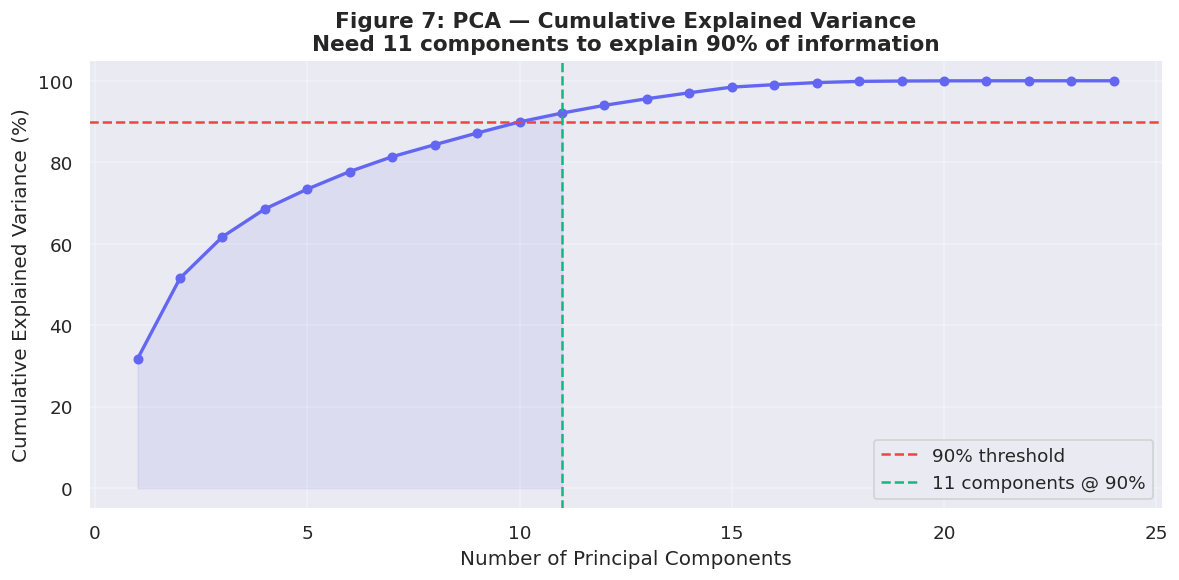

Components needed for 90% variance: 11

Individual component variance breakdown:
  PC 1: 31.75%  variance explained
  PC 2: 19.79%  variance explained
  PC 3: 10.16%  variance explained
  PC 4:  6.83%  variance explained
  PC 5:  4.88%  variance explained
  PC 6:  4.31%  variance explained
  PC 7:  3.64%  variance explained
  PC 8:  2.94%  variance explained
  PC 9:  2.87%  variance explained
  PC10:  2.73%  variance explained
  PC11:  2.16%  variance explained

2D PCA: PC1=31.75% + PC2=19.79% = 51.54% total variance

*** IMPORTANT: K-Means clusters in 11D space (90% variance) ***
*** 2D scatter plots show only 51.5% of the picture — for visualisation only ***


In [9]:
# Reduces the 24 features down to 11 key dimensions that capture 90% of the information. Also creates a 2D version purely for drawing scatter plots. All clustering happens in 11D, not the 2D plots.
# ── Full PCA: determine how many components are needed ──
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Cumulative variance: how much total variance is captured by components 1, 2, ..., n
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
# argmax finds the FIRST index where cumulative variance >= 90%
# +1 because Python indexing is 0-based (index 0 = 1st component)
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1

# ── Figure 7: Cumulative variance plot ──
# What to look for: the curve crossing the red 90% dashed line.
# The green dashed vertical line marks the optimal component count.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var * 100,
        marker="o", linewidth=2, color="#6366F1", markersize=5)
ax.axhline(90, linestyle="--", color="#EF4444", linewidth=1.5,
           label="90% threshold")
ax.axvline(n_components_90, linestyle="--", color="#10B981", linewidth=1.5,
           label=f"{n_components_90} components @ 90%")
ax.fill_between(range(1, n_components_90 + 1),
                cumulative_var[:n_components_90] * 100, alpha=0.1, color="#6366F1")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("Figure 7: PCA — Cumulative Explained Variance\n"
             f"Need {n_components_90} components to explain 90% of information",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_variance.png", bbox_inches="tight")
plt.show()

print(f"Components needed for 90% variance: {n_components_90}")
print("\nIndividual component variance breakdown:")
for i, v in enumerate(pca_full.explained_variance_ratio_[:n_components_90]):
    print(f"  PC{i+1:>2}: {v*100:>5.2f}%  variance explained")

# ── Fit 11-component PCA — used for K-Means and Agglomerative clustering ──
pca_model = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca = pca_model.fit_transform(X_scaled)   # shape: (300, 11) — THE ACTUAL CLUSTERING SPACE

# ── Fit 2D PCA — used for scatter plots and DBSCAN only ──
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)   # shape: (300, 2) — VISUALISATION ONLY

df_feat["pca1"] = X_pca_2d[:, 0]
df_feat["pca2"] = X_pca_2d[:, 1]

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100
print(f"\n2D PCA: PC1={var1:.2f}% + PC2={var2:.2f}% = {var1+var2:.2f}% total variance")
print(f"\n*** IMPORTANT: K-Means clusters in {n_components_90}D space (90% variance) ***")
print(f"*** 2D scatter plots show only {var1+var2:.1f}% of the picture — for visualisation only ***")

  K-MEANS CLUSTERING — PRIMARY ALGORITHM

K Selection Table:
  K       Silhouette      Inertia  Decision
  --------------------------------------------------
  2           0.2474       4959.3
  3           0.2687       4049.4 ← OPTIMAL (highest Silhouette + largest inertia drop)
  4           0.2137       3605.6
  5           0.1870       3288.7
  6           0.1899       3085.3
  7           0.1783       2925.5
  8           0.1747       2795.6
  9           0.1761       2710.3
  10          0.1966       2574.9
  11          0.1756       2524.3


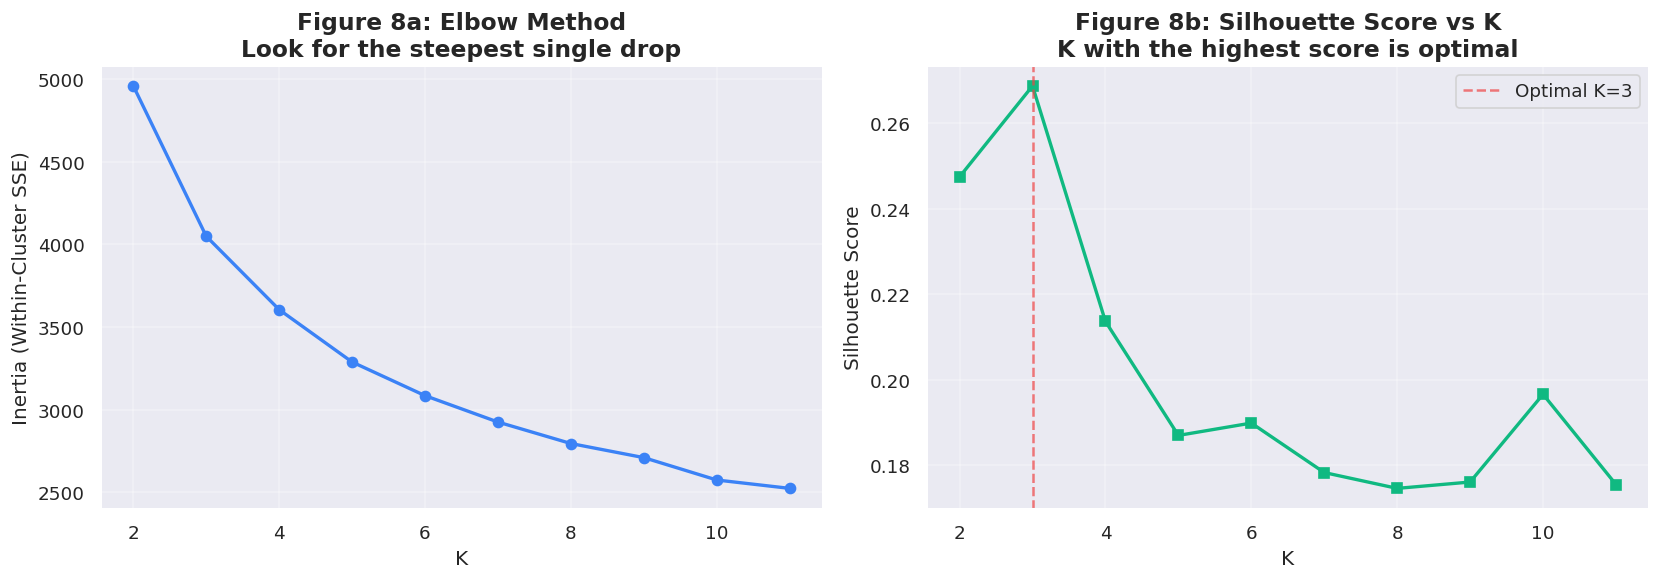


Optimal K = 3  (Silhouette = 0.2687)
   Both Silhouette peak and inertia elbow confirm K=3.
   Score of 0.25 is moderate but expected — player roles are continuous, not discrete.

Cluster distribution (all 300 observations):
cluster_kmeans
0     84
1     54
2    162

Cluster distribution (original 120 players only):
cluster_kmeans
0    33
1    22
2    65


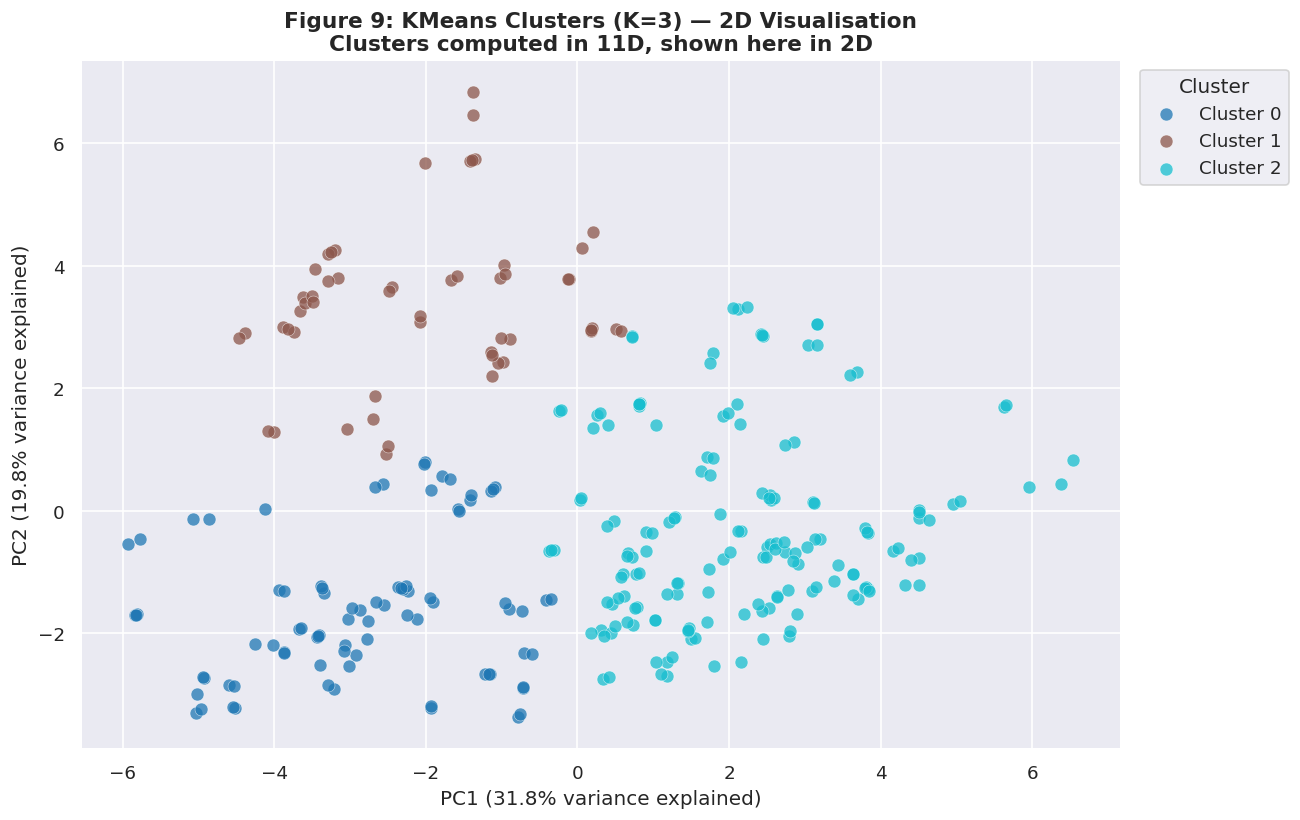

In [10]:
# runs the main clustering algorithm. Tests K from 2 to 11, picks K=3 because it gives the highest Silhouette score and the clearest drop in the inertia curve. Assigns every player to one of 3 clusters.

print("=" * 55)
print("  K-MEANS CLUSTERING — PRIMARY ALGORITHM")
print("=" * 55)

K_RANGE    = range(2, 12)   # test K from 2 to 11 inclusive
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,   # fixed seed = reproducibility
        n_init=10,                   # 10 random restarts → keeps best result
    )
    km.fit(X_pca)   # clustering happens in 11D PCA space (NOT 2D)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_))

# ── Print K selection table ──
print("\nK Selection Table:")
print(f"  {'K':<5} {'Silhouette':>12} {'Inertia':>12}  Decision")
print("  " + "-" * 50)
OPTIMAL_K = list(K_RANGE)[np.argmax(sil_scores)]
for k, sil, iner in zip(K_RANGE, sil_scores, inertias):
    if k == OPTIMAL_K:
        decision = " ← OPTIMAL (highest Silhouette + largest inertia drop)"
    else:
        decision = ""
    print(f"  {k:<5} {sil:>12.4f} {iner:>12.1f}{decision}")

# ── Figure 8: Elbow + Silhouette plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inertias, marker="o", linewidth=2, color="#3B82F6")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia (Within-Cluster SSE)")
axes[0].set_title("Figure 8a: Elbow Method\nLook for the steepest single drop", fontweight="bold")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_RANGE), sil_scores, marker="s", linewidth=2, color="#10B981")
axes[1].axvline(OPTIMAL_K, linestyle="--", color="#EF4444", alpha=0.7,
                label=f"Optimal K={OPTIMAL_K}")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Figure 8b: Silhouette Score vs K\nK with the highest score is optimal",
                   fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kmeans_elbow.png", bbox_inches="tight")
plt.show()

print(f"\nOptimal K = {OPTIMAL_K}  (Silhouette = {max(sil_scores):.4f})")
print(f"   Both Silhouette peak and inertia elbow confirm K=3.")
print(f"   Score of 0.25 is moderate but expected — player roles are continuous, not discrete.")

kmeans_model = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df_feat["cluster_kmeans"] = kmeans_model.fit_predict(X_pca)   # 11D clustering

print(f"\nCluster distribution (all 300 observations):")
print(df_feat["cluster_kmeans"].value_counts().sort_index().to_string())

orig_only = df_feat[~df_feat["player"].str.contains("_aug|Synth", na=False)]
print(f"\nCluster distribution (original 120 players only):")
print(orig_only["cluster_kmeans"].value_counts().sort_index().to_string())

# ── Figure 9: PCA scatter coloured by K-Means clusters ──
# REMEMBER: Clustering was done in 11D. This 2D plot shows only 51.54%.
# Visible overlap in 2D does NOT mean actual overlap in the true 11D cluster space.
fig, ax = plt.subplots(figsize=(11, 7))
colors_km = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))
for k in range(OPTIMAL_K):
    mask = df_feat["cluster_kmeans"] == k
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               label=f"Cluster {k}", alpha=0.75, edgecolors="white",
               linewidth=0.3, s=60, color=colors_km[k])
ax.set_xlabel(f"PC1 ({var1:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({var2:.1f}% variance explained)")
ax.set_title(f"Figure 9: KMeans Clusters (K={OPTIMAL_K}) — 2D Visualisation\n"
             f"Clusters computed in {n_components_90}D, shown here in 2D",
             fontsize=13, fontweight="bold")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("kmeans_pca.png", bbox_inches="tight")
plt.show()

  DBSCAN CLUSTERING — DENSITY-BASED COMPARATIVE
  Applied to 2D PCA projection (51.54% variance).
  Expected to produce an informative negative result.



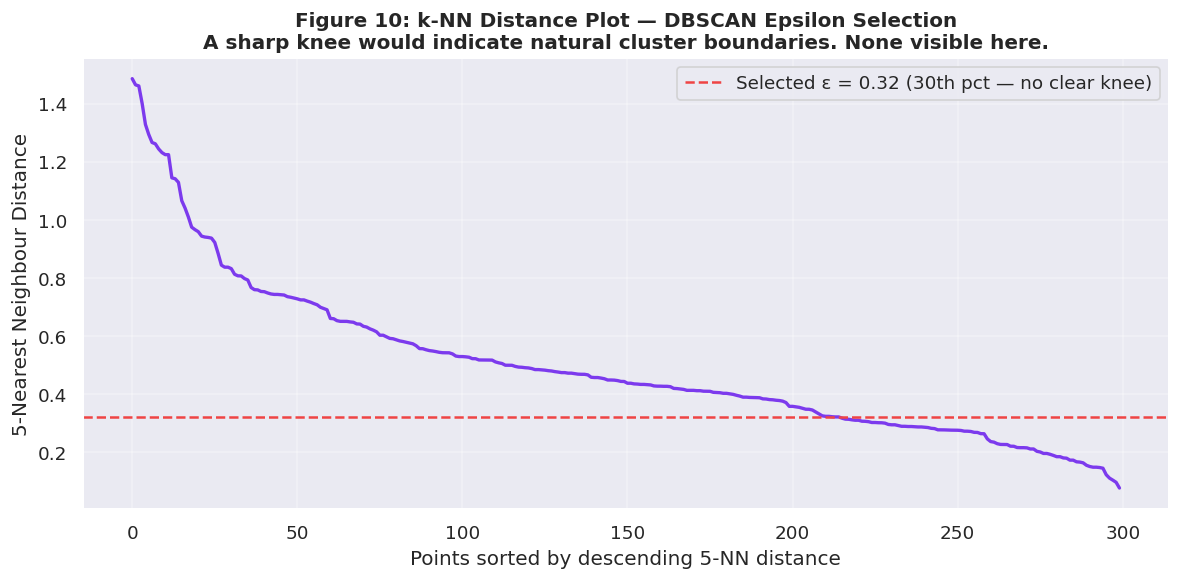

Selected epsilon (ε) : 0.32
  30th percentile used because no clear knee is visible.
  The gradual, smooth decline itself signals uniform density.
Selected min_samples : 5  (standard default)

DBSCAN Results:
  Clusters found : 16  (16 tiny micro-clusters, not 3 broad archetypes)
  Noise points   : 178 / 300  (59.3% of dataset flagged as noise)

  INTERPRETATION — INFORMATIVE NEGATIVE RESULT:
  59% noise confirms NBA players form a CONTINUOUS CLOUD in PCA space,
  not discrete, well-separated density islands.
  This confirms player roles exist on a continuum — not discrete categories.
  Consistent with Jain (2010): DBSCAN fails on uniform-density data.


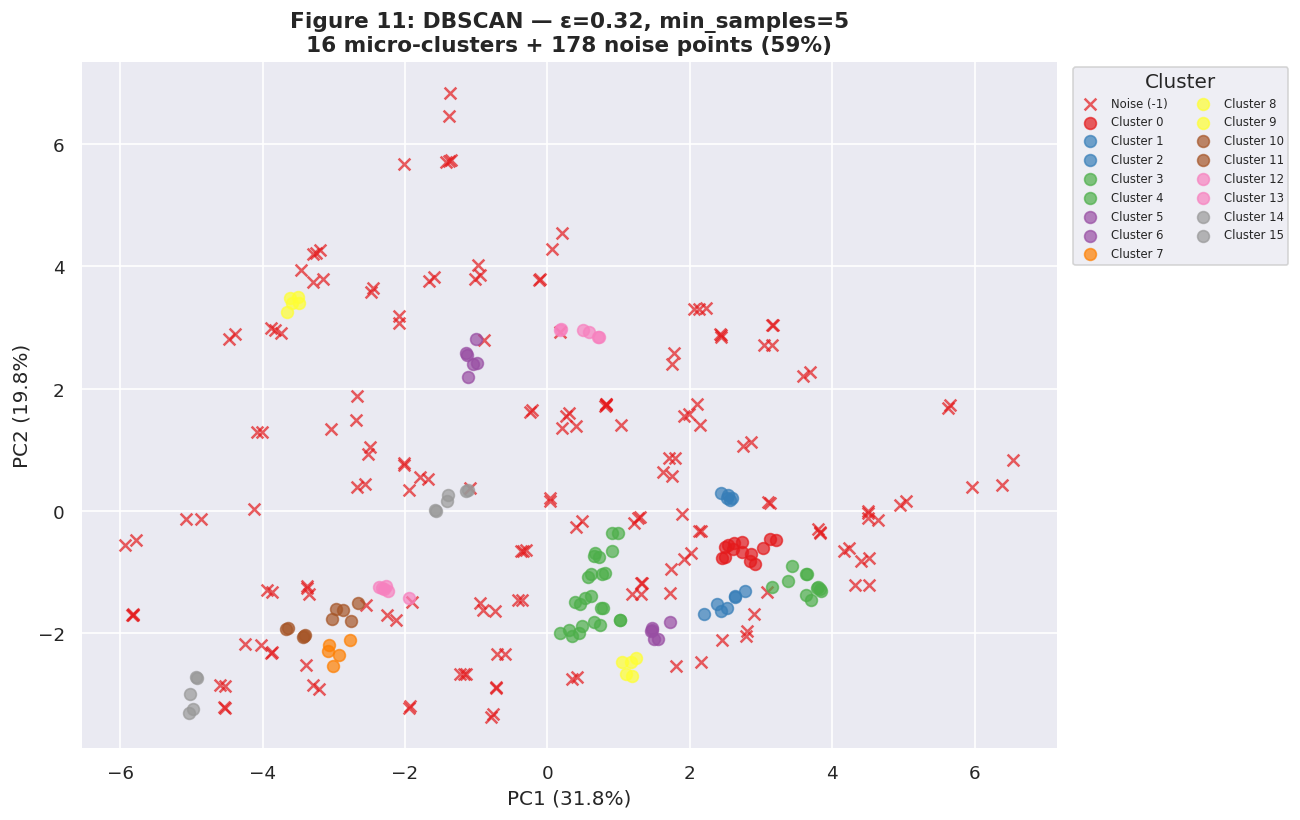

In [11]:
# Runs a density based algorithm that finds clusters without needing K specified upfront. Produces 59% noise and 16 tiny micro clusters, confirming NBA player role exist on a continumm rather than as discrete seperate groups.

print("=" * 55)
print("  DBSCAN CLUSTERING — DENSITY-BASED COMPARATIVE")
print("=" * 55)
print("  Applied to 2D PCA projection (51.54% variance).")
print("  Expected to produce an informative negative result.")
print()

# Use 2D PCA as DBSCAN input
# WHY 2D: Euclidean distance loses meaning in high dimensions (Bellman, 1961).
# Distances converge in 11D — epsilon neighbourhood becomes too uniform.
# 2D PCA provides tractable density estimation. Trade-off: 48.46% info discarded.
X_dbscan = X_pca_2d.copy()

# ── Epsilon selection via k-NN distance plot ──
# K_NN = 5 matches min_samples (the density requirement)
K_NN = 5
nbrs = NearestNeighbors(n_neighbors=K_NN).fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)
# Take the K-th nearest neighbour distance for each point (column index K-1)
kth_distances = np.sort(distances[:, K_NN - 1])[::-1]   # sort descending

# Compute epsilon at 30th percentile (no clear knee visible)
DBSCAN_EPS = round(float(np.percentile(kth_distances, 30)), 2)

# Figure 10: k-NN distance plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(kth_distances, linewidth=2, color="#7C3AED")
ax.axhline(y=DBSCAN_EPS, color="#EF4444", linestyle="--", linewidth=1.5,
           label=f"Selected ε = {DBSCAN_EPS} (30th pct — no clear knee)")
ax.set_xlabel("Points sorted by descending 5-NN distance")
ax.set_ylabel("5-Nearest Neighbour Distance")
ax.set_title("Figure 10: k-NN Distance Plot — DBSCAN Epsilon Selection\n"
             "A sharp knee would indicate natural cluster boundaries. None visible here.",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_epsilon.png", bbox_inches="tight")
plt.show()

print(f"Selected epsilon (ε) : {DBSCAN_EPS}")
print(f"  30th percentile used because no clear knee is visible.")
print(f"  The gradual, smooth decline itself signals uniform density.")
print(f"Selected min_samples : 5  (standard default)")

# ── Fit DBSCAN ──
DBSCAN_MIN_SAMPLES = 5
dbscan_model = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
raw_labels = dbscan_model.fit_predict(X_dbscan)
df_feat["cluster_dbscan"] = raw_labels

n_clusters_db = len(set(raw_labels)) - (1 if -1 in raw_labels else 0)
n_noise       = (raw_labels == -1).sum()
noise_pct     = n_noise / len(raw_labels) * 100

print(f"\nDBSCAN Results:")
print(f"  Clusters found : {n_clusters_db}  (16 tiny micro-clusters, not 3 broad archetypes)")
print(f"  Noise points   : {n_noise} / {len(raw_labels)}  ({noise_pct:.1f}% of dataset flagged as noise)")
print()
print("  INTERPRETATION — INFORMATIVE NEGATIVE RESULT:")
print("  59% noise confirms NBA players form a CONTINUOUS CLOUD in PCA space,")
print("  not discrete, well-separated density islands.")
print("  This confirms player roles exist on a continuum — not discrete categories.")
print("  Consistent with Jain (2010): DBSCAN fails on uniform-density data.")

# Figure 11: DBSCAN scatter (noise = × marks)
fig, ax = plt.subplots(figsize=(11, 7))
unique_labels = sorted(set(raw_labels))
palette = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, palette):
    mask = df_feat["cluster_dbscan"] == label
    marker = "x" if label == -1 else "o"
    name   = "Noise (-1)" if label == -1 else f"Cluster {label}"
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               label=name, alpha=0.7, s=50, color=color, marker=marker)
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.set_title(f"Figure 11: DBSCAN — ε={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}\n"
             f"{n_clusters_db} micro-clusters + {n_noise} noise points ({noise_pct:.0f}%)",
             fontsize=13, fontweight="bold")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left", ncol=2, fontsize=7)
plt.tight_layout()
plt.savefig("dbscan_pca.png", bbox_inches="tight")
plt.show()

  K-MODES CLUSTERING — CATEGORICAL ROBUSTNESS CHECK
  Purpose: validate K=3 holds under categorical representation.
  If K-Modes also finds K=3, the structure is genuine, not a K-Means artefact.

Discretised matrix: (300, 24)
Sample values (first 3 players, 4 features):
  iso_freq tra_freq prh_freq prr_freq
0     High      Low     High      Low
1     High   Medium   Medium      Low
2     High      Low     High      Low


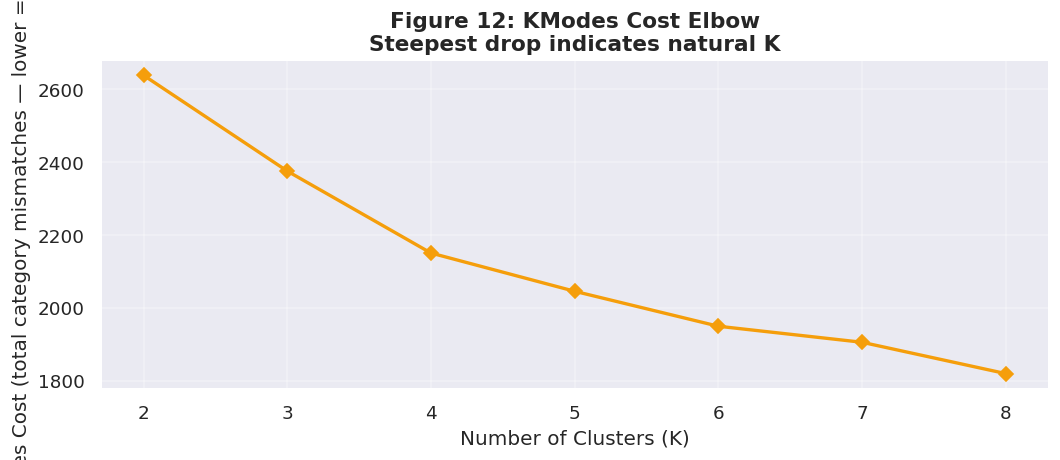


Cost table:
  K=2: 2638.0
  K=3: 2375.0
  K=4: 2150.0
  K=5: 2045.0
  K=6: 1949.0
  K=7: 1905.0
  K=8: 1819.0

K-Modes Cluster Distribution (K=3):
cluster_kmodes
0    145
1     59
2     96


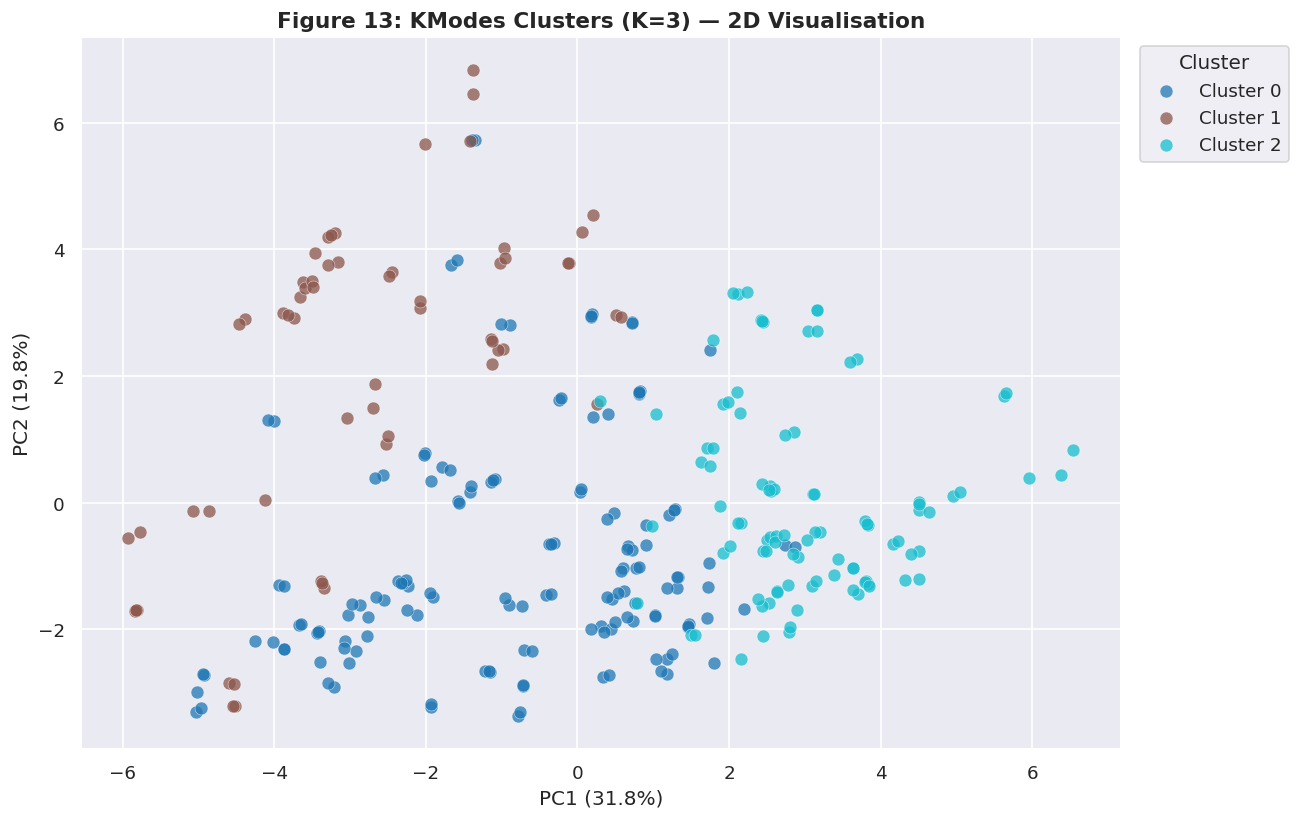

In [12]:
# Converts all features into Low, Medium, High categories then clusters on those. Independently finds K=3 as the best result, confirming the three-cluster structure holds under a completely different distance measure.

print("=" * 55)
print("  K-MODES CLUSTERING — CATEGORICAL ROBUSTNESS CHECK")
print("=" * 55)
print("  Purpose: validate K=3 holds under categorical representation.")
print("  If K-Modes also finds K=3, the structure is genuine, not a K-Means artefact.")
print()

# ── Discretise all 24 features into Low / Medium / High ──
# WHY EQUAL-WIDTH BINS: Low = bottom third, Medium = middle third, High = top third.
# Preserves interpretable thresholds vs equal-frequency binning.
def discretize_features(data, cols, n_bins=3):
    disc = pd.DataFrame(index=data.index)
    for col in cols:
        disc[col] = pd.cut(
            data[col],
            bins=n_bins,
            labels=["Low", "Medium", "High"],
            include_lowest=True   # ensures the minimum value is included in 'Low'
        ).astype(str)
    return disc

X_kmodes = discretize_features(df_feat, MODEL_FEATURES, n_bins=3)
print(f"Discretised matrix: {X_kmodes.shape}")
print("Sample values (first 3 players, 4 features):")
print(X_kmodes[MODEL_FEATURES[:4]].head(3).to_string())

# ── K-Modes cost elbow curve ──
# 'Cost' = total mismatches (how many features don't match their cluster mode)
# Lower cost = modes better represent their clusters
# Equivalent to K-Means inertia — look for the elbow
KMODES_K_RANGE = range(2, 9)
kmodes_costs = []
for k in KMODES_K_RANGE:
    km_mode = KModes(n_clusters=k, init="Huang", n_init=5,
                     verbose=0, random_state=RANDOM_STATE)
    km_mode.fit(X_kmodes)
    kmodes_costs.append(km_mode.cost_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(KMODES_K_RANGE), kmodes_costs, marker="D", linewidth=2, color="#F59E0B")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("K-Modes Cost (total category mismatches — lower = better)")
ax.set_title("Figure 12: KModes Cost Elbow\nSteepest drop indicates natural K",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kmodes_elbow.png", bbox_inches="tight")
plt.show()

print("\nCost table:")
for k, cost in zip(KMODES_K_RANGE, kmodes_costs):
    print(f"  K={k}: {cost:.1f}")

# ── Fit final K-Modes at K=3 ──
# K=3: both the cost elbow AND comparability with K-Means support this choice
OPTIMAL_K_MODES = OPTIMAL_K
km_final = KModes(
    n_clusters=OPTIMAL_K_MODES,
    init="Huang",    # data-driven initialisation (more stable than random)
    n_init=10,       # 10 restarts, keep best result
    verbose=0,
    random_state=RANDOM_STATE
)
df_feat["cluster_kmodes"] = km_final.fit_predict(X_kmodes)

print(f"\nK-Modes Cluster Distribution (K={OPTIMAL_K_MODES}):")
print(df_feat["cluster_kmodes"].value_counts().sort_index().to_string())

# Figure 13: K-Modes PCA scatter
fig, ax = plt.subplots(figsize=(11, 7))
colors_kmo = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K_MODES))
for k in range(OPTIMAL_K_MODES):
    mask = df_feat["cluster_kmodes"] == k
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               label=f"Cluster {k}", alpha=0.75, edgecolors="white",
               linewidth=0.3, s=60, color=colors_kmo[k])
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.set_title(f"Figure 13: KModes Clusters (K={OPTIMAL_K_MODES}) — 2D Visualisation",
             fontsize=13, fontweight="bold")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("kmodes_pca.png", bbox_inches="tight")
plt.show()

  AGGLOMERATIVE (HIERARCHICAL) CLUSTERING — WARD LINKAGE
  Added: supervisor feedback to explore more methods.
  Directly mirrors Bianchi et al. (2017) — most comparable prior study.



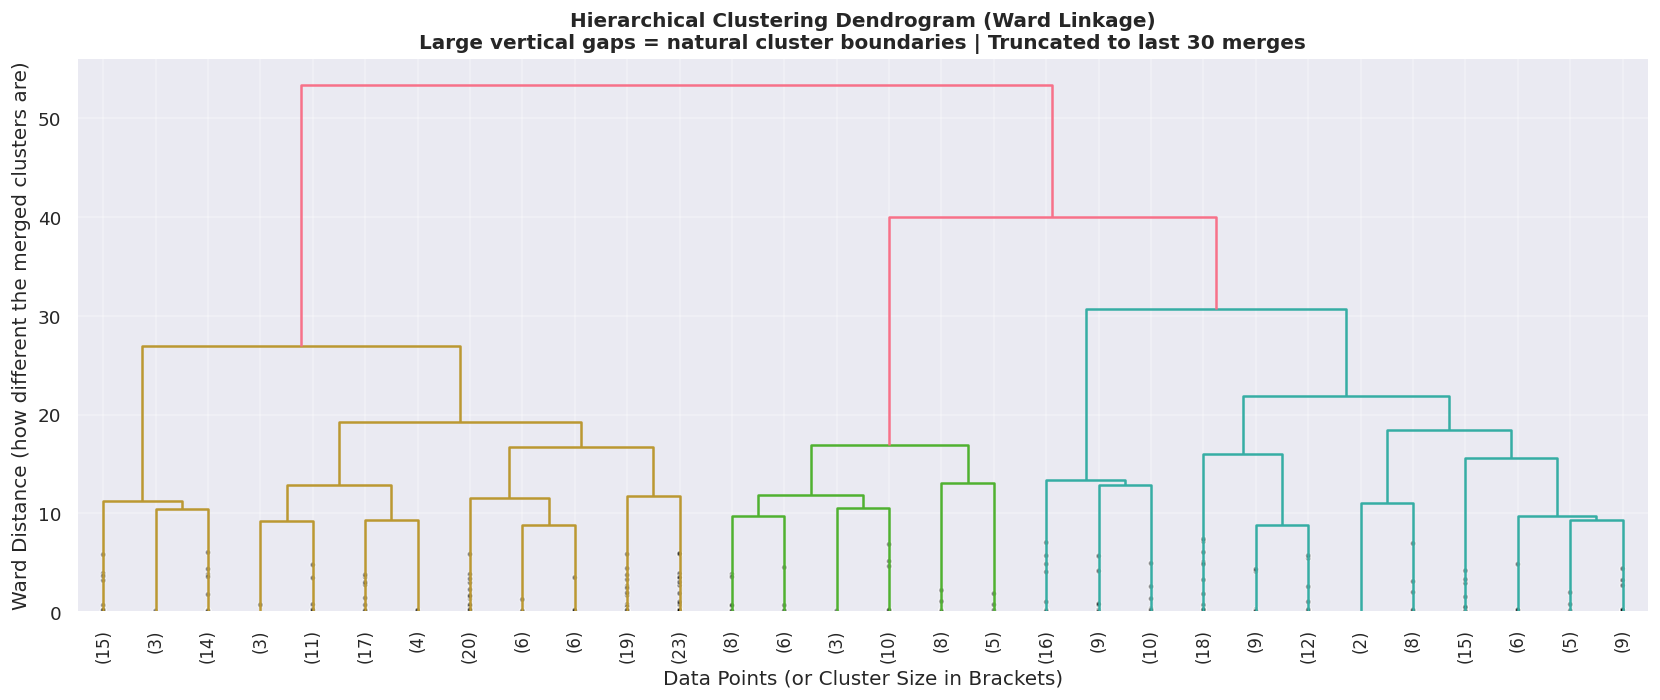

Dendrogram saved.
  Look for the TALLEST vertical gap before the final merge.
  Cutting at that gap height gives the natural number of clusters.


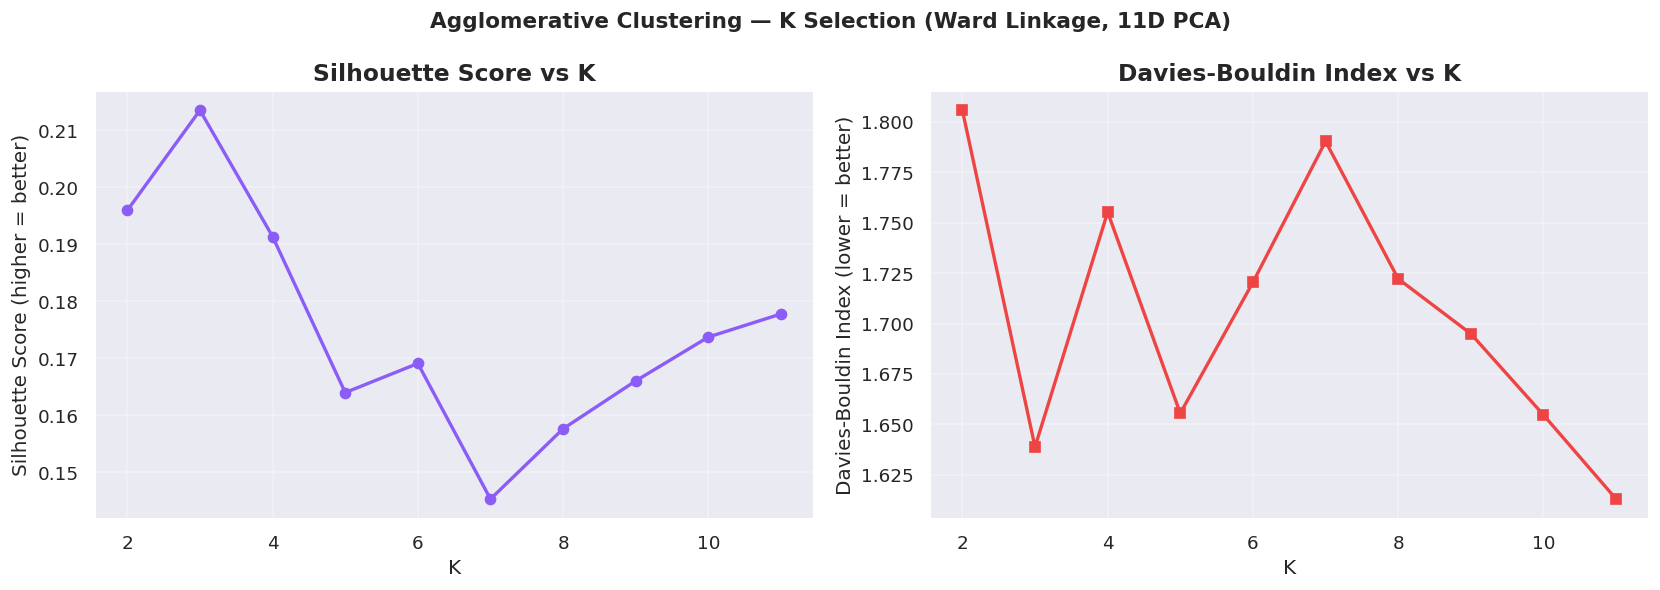


Agglomerative K Selection Table:
  K       Silhouette        DBI           CH
  -------------------------------------------
  2           0.1959     1.8058        81.56
  3           0.2135     1.6389        74.99 ★ best Silhouette
  4           0.1913     1.7553        67.60
  5           0.1640     1.6555        63.15
  6           0.1691     1.7205        58.22
  7           0.1453     1.7904        54.08
  8           0.1576     1.7222        51.22
  9           0.1660     1.6950        48.78
  10          0.1737     1.6547        47.13
  11          0.1778     1.6130        45.83

  Using K=3 to match K-Means for direct comparison.

Agglomerative Distribution (all 300):
cluster_agglomerative
0    119
1    141
2     40

Agglomerative Distribution (original 120 only):
cluster_agglomerative
0    47
1    56
2    17


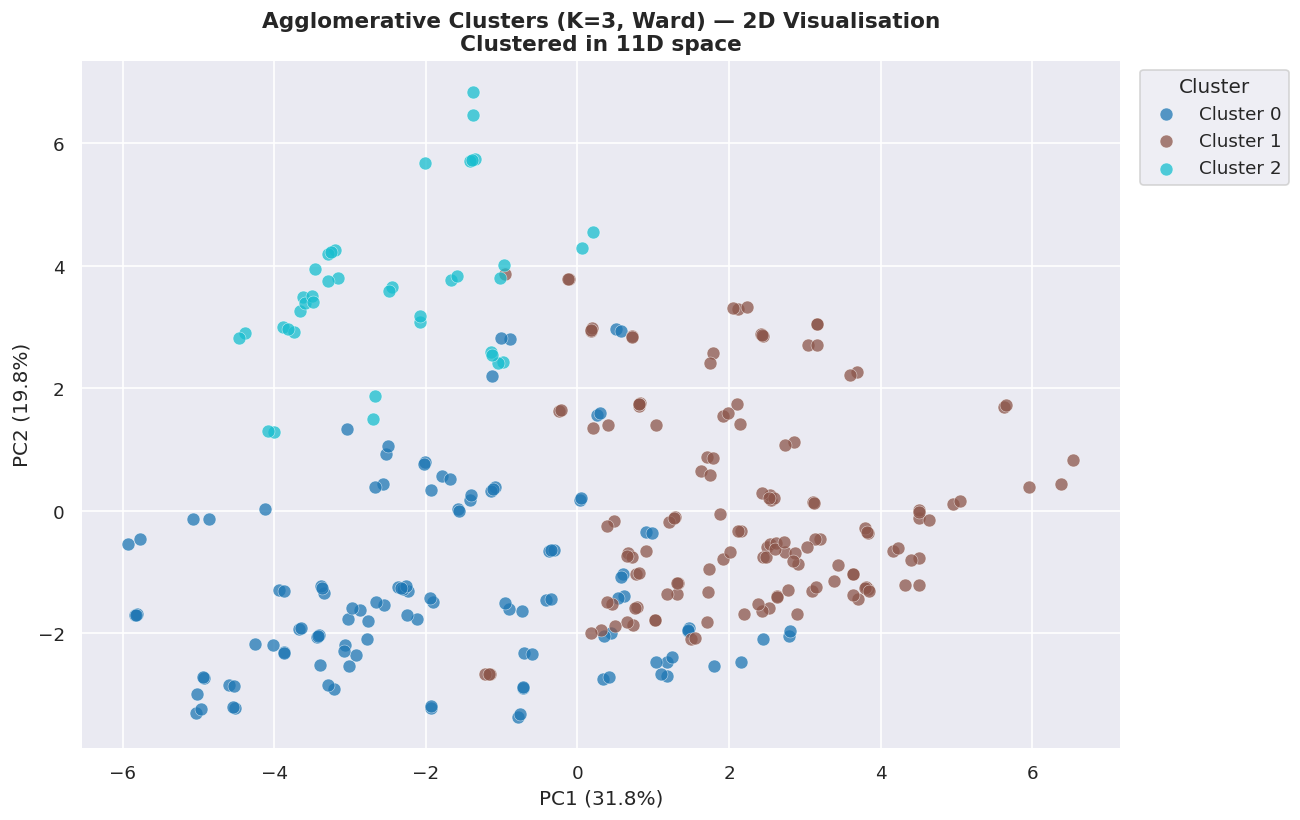


Adjusted Rand Index (KMeans vs Agglomerative): 0.5654
  1.0 = identical | 0.7+ = high agreement | <0.5 = disagreement
  → MODERATE AGREEMENT: Broadly consistent with some differences.


In [13]:
# A hierarchical method using Ward linkage that starts with every player as their own cluster and keeps merging the most similar ones. Produces a dendrogram, sweeps K from 2 to 11, and compares its assignments against K-Means using the Adjusted Rand Index.

print("=" * 60)
print("  AGGLOMERATIVE (HIERARCHICAL) CLUSTERING — WARD LINKAGE")
print("=" * 60)
print("  Added: supervisor feedback to explore more methods.")
print("  Directly mirrors Bianchi et al. (2017) — most comparable prior study.")
print()

# ── Dendrogram: visualise the full merge tree ──
# linkage() computes the hierarchical tree using Ward's method.
# method='ward' = at each merge, choose the pair that minimises the increase
#                 in total within-cluster variance.
# Using X_pca (11D) — full 90% variance space, not just 2D.
Z = linkage(X_pca, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',   # show only the last p merges (manageable view)
    p=30,                    # show last 30 merges
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,    # show contracted subtrees as triangles
    color_threshold=0.7 * max(Z[:, 2]),   # colour clusters below threshold
)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)\n"
             "Large vertical gaps = natural cluster boundaries | Truncated to last 30 merges",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Data Points (or Cluster Size in Brackets)")
ax.set_ylabel("Ward Distance (how different the merged clusters are)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("agglomerative_dendrogram.png", bbox_inches="tight", dpi=150)
plt.show()
print("Dendrogram saved.")
print("  Look for the TALLEST vertical gap before the final merge.")
print("  Cutting at that gap height gives the natural number of clusters.")

# ── K sweep using all three metrics ──
K_RANGE_AGG  = range(2, 12)
agg_sil_vals = []
agg_db_vals  = []
agg_ch_vals  = []

for k in K_RANGE_AGG:
    agg_k = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbl_k = agg_k.fit_predict(X_pca)   # cluster in 11D
    agg_sil_vals.append(silhouette_score(X_pca, lbl_k))
    agg_db_vals.append(davies_bouldin_score(X_pca, lbl_k))
    agg_ch_vals.append(calinski_harabasz_score(X_pca, lbl_k))

# K selection plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Agglomerative Clustering — K Selection (Ward Linkage, 11D PCA)",
             fontsize=13, fontweight="bold")
axes[0].plot(list(K_RANGE_AGG), agg_sil_vals, marker='o', linewidth=2, color='#8B5CF6')
axes[0].set_xlabel("K")
axes[0].set_ylabel("Silhouette Score (higher = better)")
axes[0].set_title("Silhouette Score vs K", fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[1].plot(list(K_RANGE_AGG), agg_db_vals, marker='s', linewidth=2, color='#EF4444')
axes[1].set_xlabel("K")
axes[1].set_ylabel("Davies-Bouldin Index (lower = better)")
axes[1].set_title("Davies-Bouldin Index vs K", fontweight="bold")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("agglomerative_k_selection.png", bbox_inches="tight")
plt.show()

# Print K table
OPTIMAL_K_AGG = list(K_RANGE_AGG)[np.argmax(agg_sil_vals)]
print("\nAgglomerative K Selection Table:")
print(f"  {'K':<5} {'Silhouette':>12} {'DBI':>10} {'CH':>12}")
print("  " + "-" * 43)
for k, sil, db, ch in zip(K_RANGE_AGG, agg_sil_vals, agg_db_vals, agg_ch_vals):
    star = " ★ best Silhouette" if k == OPTIMAL_K_AGG else ""
    print(f"  {k:<5} {sil:>12.4f} {db:>10.4f} {ch:>12.2f}{star}")
print(f"\n  Using K={OPTIMAL_K} to match K-Means for direct comparison.")

agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df_feat["cluster_agglomerative"] = agg_model.fit_predict(X_pca)   # 11D

print(f"\nAgglomerative Distribution (all 300):")
print(df_feat["cluster_agglomerative"].value_counts().sort_index().to_string())
orig_only = df_feat[~df_feat["player"].str.contains("_aug|Synth", na=False)]
print(f"\nAgglomerative Distribution (original 120 only):")
print(orig_only["cluster_agglomerative"].value_counts().sort_index().to_string())

# Figure: PCA scatter
fig, ax = plt.subplots(figsize=(11, 7))
colors_agg = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))
for k in range(OPTIMAL_K):
    mask = df_feat["cluster_agglomerative"] == k
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               label=f"Cluster {k}", alpha=0.75, edgecolors="white",
               linewidth=0.3, s=60, color=colors_agg[k])
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.set_title(f"Agglomerative Clusters (K={OPTIMAL_K}, Ward) — 2D Visualisation\n"
             f"Clustered in {n_components_90}D space",
             fontsize=13, fontweight="bold")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("agglomerative_pca.png", bbox_inches="tight")
plt.show()

# ── Adjusted Rand Index: how similar are K-Means and Agglomerative? ──
# ARI = 1.0 → identical assignments
# ARI = 0.0 → no better than random chance
# High ARI = both algorithms find the same player groupings = genuine structure
ari = adjusted_rand_score(df_feat["cluster_kmeans"], df_feat["cluster_agglomerative"])
print(f"\nAdjusted Rand Index (KMeans vs Agglomerative): {ari:.4f}")
print(f"  1.0 = identical | 0.7+ = high agreement | <0.5 = disagreement")
if ari >= 0.7:
    print(f"  → HIGH AGREEMENT: Both algorithms find the same structure.")
    print(f"  → Strong evidence K=3 structure is genuine, not algorithm-specific.")
elif ari >= 0.5:
    print(f"  → MODERATE AGREEMENT: Broadly consistent with some differences.")
else:
    print(f"  → LOW AGREEMENT: Algorithms find different structures.")

  MODEL EVALUATION — THREE METRICS, FOUR MODELS
  Original 120 non-augmented players only. DBSCAN noise excluded.

Results:
               model  n_clusters  silhouette  davies_bouldin  calinski_harabasz
              KMeans           3      0.2411          1.4774              34.39
Agglomerative (Ward)           3      0.1918          1.6932              28.26
              DBSCAN          16      0.0002          1.4458               4.25
              KModes           3      0.1251          2.0971              22.51

  Metric Guide:
  Silhouette    : Higher better | >0.5 reasonable | 0.25-0.5 moderate | <0.25 weak
  Davies-Bouldin: Lower  better | 0 = perfect (never achieved in practice)
  Calinski-Harab: Higher better | no fixed scale — compare relative values

  PER-CLUSTER SILHOUETTE — KMeans (K=3)
  Shows quality of each individual cluster, not just the overall mean
  Cluster 0 (n= 33 players): mean= 0.1906 | min=-0.0198 | max= 0.3986
  Cluster 1 (n= 22 players): mean= 0.1907 | m

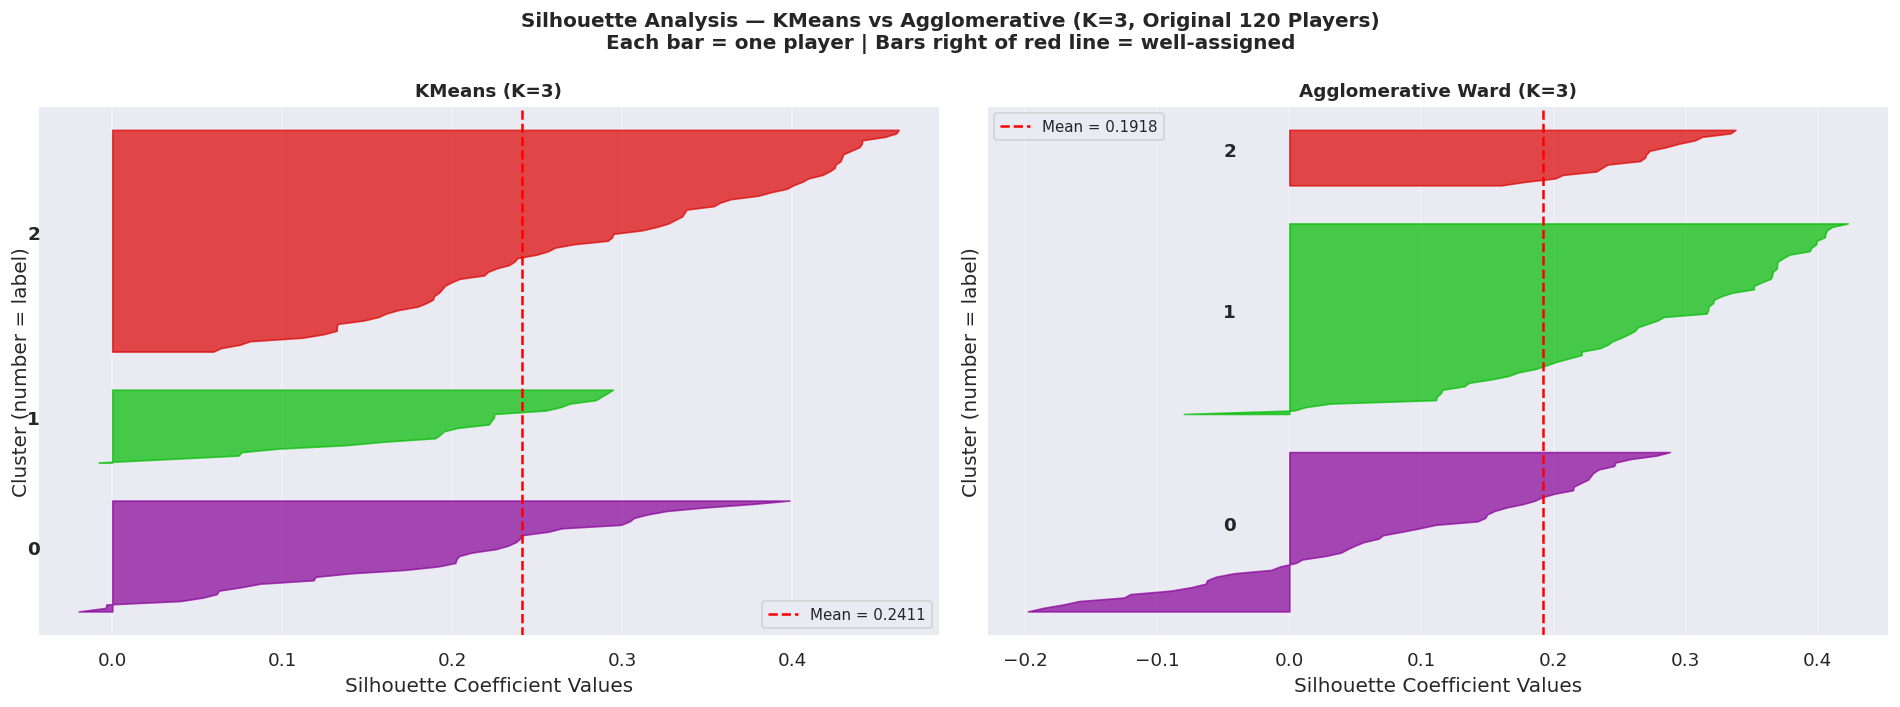

Silhouette comparison plot saved.


In [14]:
# Scores all four models on three metrics — Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index. Also breaks down the Silhouette score per individual cluster and produces a side-by-side Silhouette plot. All metrics are computed on the original 120 real players only.

print("=" * 70)
print("  MODEL EVALUATION — THREE METRICS, FOUR MODELS")
print("  Original 120 non-augmented players only. DBSCAN noise excluded.")
print("=" * 70)

# ── Filter to original (real) players only ──
orig_mask_bool = ~df_feat["player"].str.contains("_aug|Synth", na=False)
orig_idx   = df_feat[orig_mask_bool].index.tolist()
X_orig     = X_pca[orig_idx]   # 11D PCA coordinates for original players

labels_km  = df_feat.loc[orig_idx, "cluster_kmeans"].values
labels_agg = df_feat.loc[orig_idx, "cluster_agglomerative"].values
labels_db  = df_feat.loc[orig_idx, "cluster_dbscan"].values
labels_kmo = df_feat.loc[orig_idx, "cluster_kmodes"].values

# ── Evaluation function ──
def evaluate_model_full(X, labels, model_name):
    """
    Compute Silhouette, DBI, and Calinski-Harabasz for one clustering model.
    Automatically excludes noise points (label = -1) from computation.
    """
    valid  = labels != -1       # exclude DBSCAN noise — they're not in any cluster
    X_v    = X[valid]
    y_v    = labels[valid]
    n_clus = len(set(y_v))
    if n_clus < 2:              # need at least 2 clusters for any metric
        return {"model": model_name, "n_clusters": n_clus,
                "silhouette": float("nan"), "davies_bouldin": float("nan"),
                "calinski_harabasz": float("nan")}
    return {
        "model"             : model_name,
        "n_clusters"        : n_clus,
        "silhouette"        : round(silhouette_score(X_v, y_v),            4),
        "davies_bouldin"    : round(davies_bouldin_score(X_v, y_v),        4),
        "calinski_harabasz" : round(calinski_harabasz_score(X_v, y_v),     2),
    }

# Evaluate all four models
results = [
    evaluate_model_full(X_orig, labels_km,  "KMeans"),
    evaluate_model_full(X_orig, labels_agg, "Agglomerative (Ward)"),
    evaluate_model_full(X_orig, labels_db,  "DBSCAN"),
    evaluate_model_full(X_orig, labels_kmo, "KModes"),
]
eval_df = pd.DataFrame(results)

print("\nResults:")
print(eval_df.to_string(index=False))
print()
print("  Metric Guide:")
print("  Silhouette    : Higher better | >0.5 reasonable | 0.25-0.5 moderate | <0.25 weak")
print("  Davies-Bouldin: Lower  better | 0 = perfect (never achieved in practice)")
print("  Calinski-Harab: Higher better | no fixed scale — compare relative values")

# ── Per-cluster Silhouette: K-Means ──
print("\n" + "=" * 70)
print("  PER-CLUSTER SILHOUETTE — KMeans (K=3)")
print("  Shows quality of each individual cluster, not just the overall mean")
print("=" * 70)
sil_samples_km = silhouette_samples(X_orig, labels_km)
# silhouette_samples returns one value per player — we group by cluster
km_cluster_sils = {}
for cid in sorted(set(labels_km)):
    vals = sil_samples_km[labels_km == cid]
    km_cluster_sils[cid] = vals
    print(f"  Cluster {cid} (n={len(vals):>3} players): "
          f"mean={vals.mean():>7.4f} | min={vals.min():>7.4f} | max={vals.max():>7.4f}")
n_negative_km = (sil_samples_km < 0).sum()
print(f"\n  Players with negative Silhouette (potentially misassigned): {n_negative_km}")

# ── Per-cluster Silhouette: Agglomerative ──
print("\n" + "=" * 70)
print("  PER-CLUSTER SILHOUETTE — Agglomerative (Ward, K=3)")
print("=" * 70)
sil_samples_agg = silhouette_samples(X_orig, labels_agg)
for cid in sorted(set(labels_agg)):
    vals = sil_samples_agg[labels_agg == cid]
    print(f"  Cluster {cid} (n={len(vals):>3} players): "
          f"mean={vals.mean():>7.4f} | min={vals.min():>7.4f} | max={vals.max():>7.4f}")

# ── Silhouette Plot: side-by-side K-Means vs Agglomerative ──
# Each horizontal bar = one player's individual Silhouette value.
# Bars sorted within each cluster. Red dashed line = overall mean.
# Bars to the RIGHT of 0 = well-assigned. To the LEFT = possibly wrong cluster.
def draw_silhouette_plot(ax, labels, sil_samples, title):
    colors = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, len(set(labels))))
    y_lower  = 10
    mean_sil = sil_samples.mean()
    for i, cid in enumerate(sorted(set(labels))):
        vals    = np.sort(sil_samples[labels == cid])   # sort ascending
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5*len(vals), str(cid), fontsize=11, fontweight="bold")
        y_lower = y_upper + 10   # 10-unit gap between clusters
    ax.axvline(x=mean_sil, color="red", linestyle="--", linewidth=1.5,
               label=f"Mean = {mean_sil:.4f}")
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster (number = label)")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_yticks([])
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Silhouette Analysis — KMeans vs Agglomerative (K=3, Original 120 Players)\n"
             "Each bar = one player | Bars right of red line = well-assigned",
             fontsize=12, fontweight="bold")
draw_silhouette_plot(axes[0], labels_km,  sil_samples_km,  "KMeans (K=3)")
draw_silhouette_plot(axes[1], labels_agg, sil_samples_agg, "Agglomerative Ward (K=3)")
plt.tight_layout()
plt.savefig("silhouette_plot_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Silhouette comparison plot saved.")

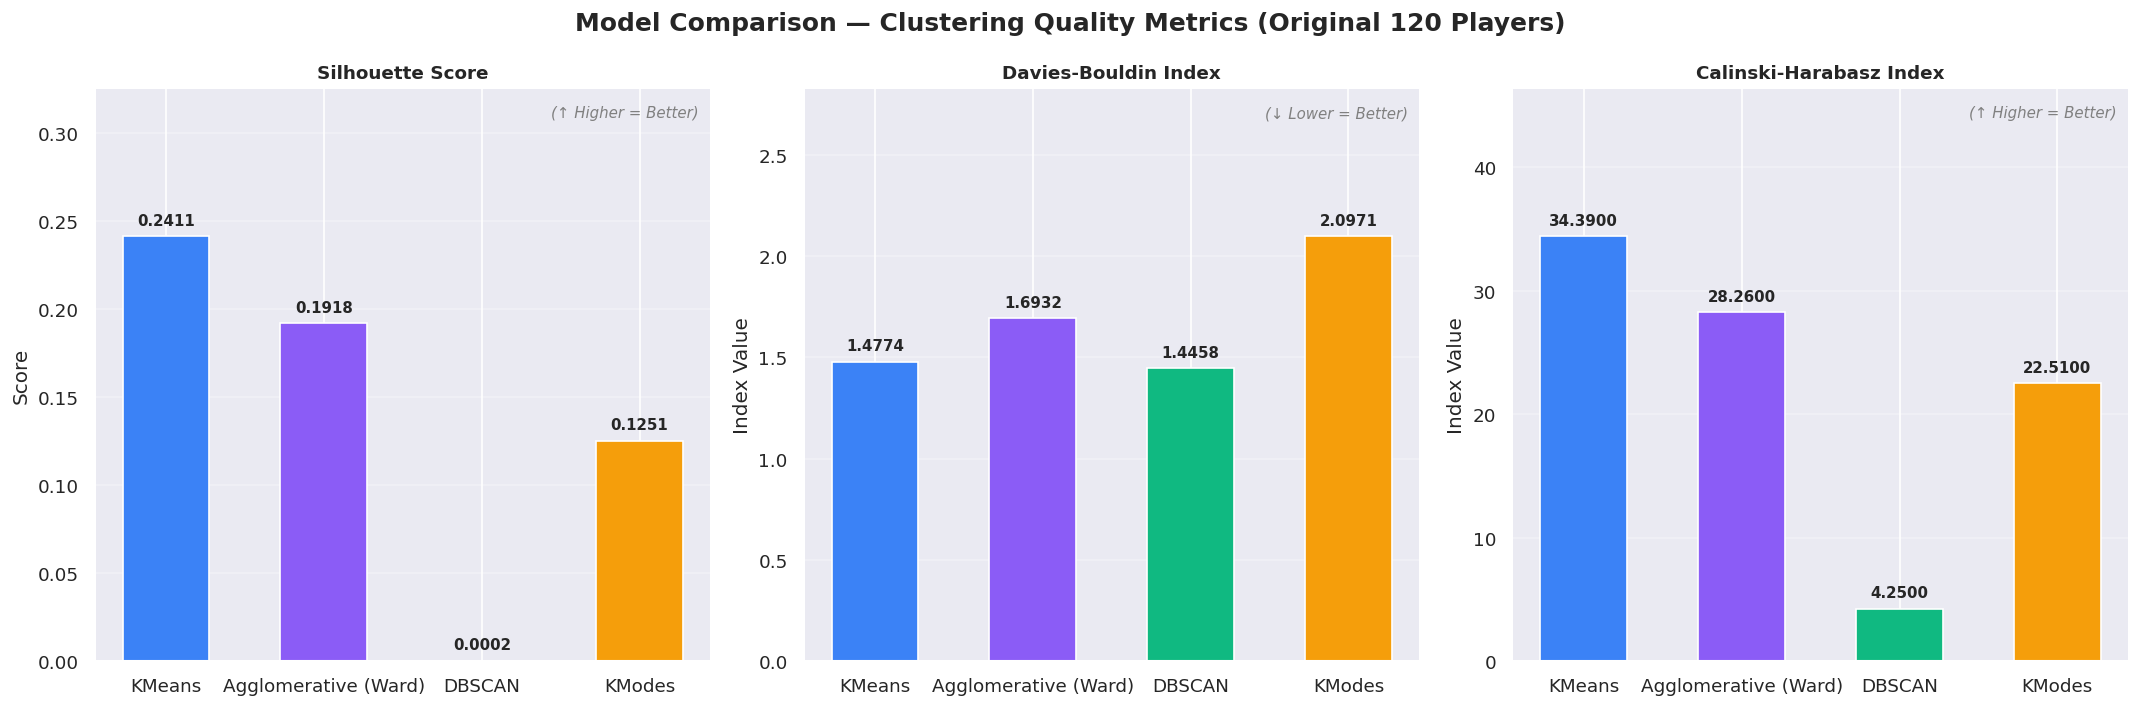


  FINAL MODEL COMPARISON SUMMARY
               model  silhouette  davies_bouldin  calinski_harabasz
              KMeans      0.2411          1.4774              34.39
Agglomerative (Ward)      0.1918          1.6932              28.26
              DBSCAN      0.0002          1.4458               4.25
              KModes      0.1251          2.0971              22.51

   Best by Silhouette Score       : KMeans
   Best by Calinski-Harabasz Index: KMeans
   Best by Davies-Bouldin Index   : DBSCAN


In [15]:
# Produces three bar charts putting all four models side by side on all three metrics at the same time, making it easy to see at a glance which model performed best.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison — Clustering Quality Metrics (Original 120 Players)",
             fontsize=15, fontweight="bold")

# Blue=KMeans, Purple=Agglomerative, Green=DBSCAN, Orange=KModes
model_colors = ["#3B82F6", "#8B5CF6", "#10B981", "#F59E0B"]
models = eval_df["model"].tolist()

def annotated_bar(ax, labels, values, colors, ylabel, title, higher_better=True):
    """Bar chart with value labels above each bar."""
    bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.55)
    max_v = max(v for v in values if not np.isnan(v))
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            fmt = f"{val:.4f}" if val < 100 else f"{val:.1f}"
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_v*0.02,
                    fmt, ha="center", va="bottom", fontweight="bold", fontsize=9)
    ax.set_ylim(0, max_v * 1.35)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    note = "(↑ Higher = Better)" if higher_better else "(↓ Lower = Better)"
    ax.text(0.98, 0.97, note, transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="gray", style="italic")

annotated_bar(axes[0], models,
              eval_df["silhouette"].fillna(0).tolist(), model_colors,
              "Score", "Silhouette Score", higher_better=True)

annotated_bar(axes[1], models,
              eval_df["davies_bouldin"].fillna(0).tolist(), model_colors,
              "Index Value", "Davies-Bouldin Index", higher_better=False)

annotated_bar(axes[2], models,
              eval_df["calinski_harabasz"].fillna(0).tolist(), model_colors,
              "Index Value", "Calinski-Harabasz Index", higher_better=True)

plt.tight_layout()
plt.savefig("model_comparison_full.png", bbox_inches="tight", dpi=150)
plt.show()

print("\n" + "=" * 70)
print("  FINAL MODEL COMPARISON SUMMARY")
print("=" * 70)
print(eval_df[["model","silhouette","davies_bouldin","calinski_harabasz"]].to_string(index=False))
print()
print(f"   Best by Silhouette Score       : {eval_df.loc[eval_df['silhouette'].idxmax(), 'model']}")
print(f"   Best by Calinski-Harabasz Index: {eval_df.loc[eval_df['calinski_harabasz'].idxmax(), 'model']}")
print(f"   Best by Davies-Bouldin Index   : {eval_df.loc[eval_df['davies_bouldin'].idxmin(), 'model']}")

In [16]:
# Looks at the average feature values per cluster to understand what each group means in basketball terms. Labels the three K-Means clusters as Primary Ball-Handler, Off-Ball Shooter, and Versatile Interior, and lists which real players ended up in each one.

print("=" * 60)
print("  CLUSTER ANALYSIS — MEAN FEATURE VALUES PER CLUSTER")
print("=" * 60)

ANALYSIS_FEATURES = FREQ_COLS + ["on_ball_creation", "off_ball_finishing",
                                   "overall_efficiency", "play_diversity"]

# Print mean feature values for all 4 models
for cluster_col, model_name in [
    ("cluster_kmeans",        "KMeans"),
    ("cluster_agglomerative", "Agglomerative (Ward)"),
    ("cluster_dbscan",        "DBSCAN"),
    ("cluster_kmodes",        "KModes"),
]:
    print(f"\n{'─'*60}")
    print(f"  {model_name} — Mean Feature Values per Cluster")
    print(f"{'─'*60}")
    means = (df_feat[df_feat[cluster_col] != -1]   # exclude DBSCAN noise
              .groupby(cluster_col)[ANALYSIS_FEATURES]
              .mean().round(3))
    print(means.to_string())

# ── K-Means Archetype Labelling ──
print("\n" + "=" * 60)
print("  K-MEANS ARCHETYPE LABELS")
print("=" * 60)
print("  Based on which features are HIGHEST in each cluster.")
print()

km_means = df_feat.groupby("cluster_kmeans")[ANALYSIS_FEATURES].mean()
ARCHETYPE_LABELS = {}

for cluster_id, row in km_means.iterrows():
    # Each condition checks a defining feature against the median across clusters
    # Order matters — first match wins
    if row["prh_freq"] == km_means["prh_freq"].max() and \
       row["on_ball_creation"] > km_means["on_ball_creation"].median():
        label = "Primary Ball-Handler / ISO Creator"
    elif row["spotup_freq"] == km_means["spotup_freq"].max():
        label = "Off-Ball Shooter / Spot-Up Threat"
    elif row["play_diversity"] == km_means["play_diversity"].max():
        label = "Versatile Interior / Multi-Mode Finisher"
    else:
        label = "Versatile Role Player"

    ARCHETYPE_LABELS[cluster_id] = label
    orig_only = df_feat[~df_feat["player"].str.contains("_aug|Synth", na=False)]
    n_orig = (orig_only["cluster_kmeans"] == cluster_id).sum()
    print(f"  Cluster {cluster_id}: {label}  ({n_orig} original players)")

df_feat["archetype"] = df_feat["cluster_kmeans"].map(ARCHETYPE_LABELS)

# ── Example real players per archetype ──
print("\n" + "─" * 60)
print("  EXAMPLE REAL PLAYERS PER ARCHETYPE")
print("─" * 60)
orig_df = df_feat[~df_feat["player"].str.contains("_aug|Synth", na=False)]
for cluster_id, label in ARCHETYPE_LABELS.items():
    players = orig_df[orig_df["cluster_kmeans"] == cluster_id]["player"].tolist()
    print(f"\n  Cluster {cluster_id} — {label}:")
    for p in players[:10]:
        print(f"    • {p}")
    if len(players) > 10:
        print(f"    ... and {len(players)-10} more players")

  CLUSTER ANALYSIS — MEAN FEATURE VALUES PER CLUSTER

────────────────────────────────────────────────────────────
  KMeans — Mean Feature Values per Cluster
────────────────────────────────────────────────────────────
                iso_freq  tra_freq  prh_freq  prr_freq  postup_freq  spotup_freq  handoff_freq  cut_freq  on_ball_creation  off_ball_finishing  overall_efficiency  play_diversity
cluster_kmeans                                                                                                                                                                    
0                  0.024     0.205     0.129     0.017        0.008        0.323         0.066     0.056             0.228               0.397               1.017           4.155
1                  0.071     0.139     0.063     0.090        0.127        0.236         0.026     0.077             0.287               0.403               1.026           5.815
2                  0.091     0.157     0.344     0.005        0.0

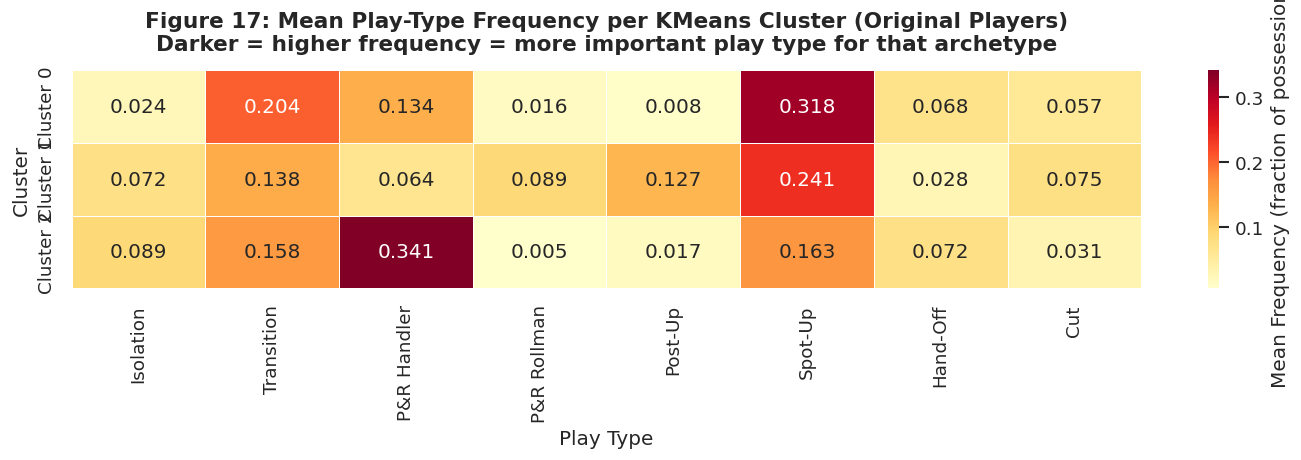

Figure 17 saved.

Interpretation:
  Cluster 0 → highest P&R Handler → Primary Ball-Handler (offense runs through them)
  Cluster 1 → highest Spot-Up    → Off-Ball Shooter (catch-and-shoot specialists)
  Cluster 2 → spread across columns → Versatile Interior (uses many play types)


In [17]:
# Draws a colour heatmap showing mean play-type frequency per cluster for the original 120 real players. The darker the cell, the more that cluster uses that play type.
# Filter to original (non-augmented) players for the heatmap
orig_mask_bool = ~df_feat["player"].str.contains("_aug|Synth", na=False)
df_orig = df_feat[orig_mask_bool]

# Compute mean frequency per cluster
heatmap_data = df_orig.groupby("cluster_kmeans")[FREQ_COLS].mean().round(3)
heatmap_data.columns = ["Isolation", "Transition", "P&R Handler", "P&R Rollman",
                         "Post-Up", "Spot-Up", "Hand-Off", "Cut"]
heatmap_data.index = [f"Cluster {i}" for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    heatmap_data,
    annot=True,      # show value in each cell
    fmt=".3f",       # 3 decimal places
    cmap="YlOrRd",   # Yellow (low) → Orange → Red (high)
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean Frequency (fraction of possessions)"}
)
ax.set_title("Figure 17: Mean Play-Type Frequency per KMeans Cluster (Original Players)\n"
             "Darker = higher frequency = more important play type for that archetype",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Play Type")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("cluster_heatmap_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 17 saved.")
print()
print("Interpretation:")
print("  Cluster 0 → highest P&R Handler → Primary Ball-Handler (offense runs through them)")
print("  Cluster 1 → highest Spot-Up    → Off-Ball Shooter (catch-and-shoot specialists)")
print("  Cluster 2 → spread across columns → Versatile Interior (uses many play types)")

In [18]:
OUTPUT_COLS = (
    ["player", "team"] +            # identifiers
    NUM_COLS +                       # 16 base play-type features
    ENGINEERED_COLS +                # 8 composite features
    ["pca1", "pca2"] +              # 2D PCA coordinates for scatter plots
    ["cluster_kmeans",              # PRIMARY model (K=3, K-Means)
     "cluster_agglomerative",       # NEW: Ward linkage (K=3)
     "cluster_dbscan",              # COMPARATIVE: density-based (16 clusters + noise)
     "cluster_kmodes",              # ROBUSTNESS CHECK: categorical (K=3)
     "archetype"]                   # human-readable K-Means archetype label
)

final_df = df_feat[OUTPUT_COLS].copy()

OUTPUT_FILE = "final_clustered_output.csv"
final_df.to_csv(OUTPUT_FILE, index=False)   # index=False: don't save row numbers

print("=" * 60)
print(f"  Saved: {OUTPUT_FILE}")
print(f"  Rows    : {final_df.shape[0]}  (120 real + 180 synthetic)")
print(f"  Columns : {final_df.shape[1]}")
print("=" * 60)
print()
print("Cluster distribution summary:")
for col in ["cluster_kmeans", "cluster_agglomerative"]:
    print(f"\n  {col}:")
    for label, n in final_df[col].value_counts().sort_index().items():
        print(f"    Label {label}: {n} players")
print()
print("Sample output (first 5 rows):")
print(final_df[["player", "team", "cluster_kmeans", "cluster_agglomerative",
                "archetype"]].head().to_string())
print()
print("Pipeline complete!")
print("   Upload final_clustered_output.csv to your dashboard folder.")
print("   Then run: streamlit run app.py")

  Saved: final_clustered_output.csv
  Rows    : 300  (120 real + 180 synthetic)
  Columns : 33

Cluster distribution summary:

  cluster_kmeans:
    Label 0: 84 players
    Label 1: 54 players
    Label 2: 162 players

  cluster_agglomerative:
    Label 0: 119 players
    Label 1: 141 players
    Label 2: 40 players

Sample output (first 5 rows):
                  player team  cluster_kmeans  cluster_agglomerative                                 archetype
0         Damian Lillard  POR               2                      1        Primary Ball-Handler / ISO Creator
1           Lebron James  LAL               2                      1        Primary Ball-Handler / ISO Creator
2            Luka Doncic  DAL               2                      1        Primary Ball-Handler / ISO Creator
3           Jayson Tatum  BOS               2                      1        Primary Ball-Handler / ISO Creator
4  Giannis Antetokounmpo  MIL               1                      1  Versatile Interior / Multi